In [1]:
%load_ext autoreload 
%autoreload 2
%matplotlib inline
import json, os, cv2
from pathlib import Path
import numpy as np
import pandas as pd
from tqdm import tqdm
from scipy.interpolate import interp1d
from scipy import signal
from scipy.signal import find_peaks
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from sklearn.cluster import KMeans
import matplotlib.colors as mcolors
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.gridspec import GridSpec 
import glob 
import seaborn as sns
from brokenaxes import brokenaxes
from frechetdist import frdist
from scipy.ndimage import gaussian_filter
from dipy.segment.metricspeed import AveragePointwiseEuclideanMetric
import ast
import scipy.stats as stats
from scipy.stats import f_oneway
from matplotlib import cm
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.cm import ScalarMappable
from sklearn.decomposition import PCA



import sys
sys.path.insert(0, 'C:/Users/nlab/Documents/GitHub/obstacle_avoidance')

import warnings
warnings.filterwarnings('ignore')
from streamline_clustering.clustering import pair_elements,create_streamlines
from src.base import BaseInput
from src.topcam import Topcam
from src.utils.auxiliary import find_index_in_list,flatten_series
from pipeline.helper_functions import list_columns,interpolate_array,flatten_list_of_arrays,calculate_quartiles,create_df_by_type,split_range_into_parts,get_mean_of_df,get_median_of_df,drop_nans_in_columns,create_consective_df_new,assign_date_index,symmetrize_y_axis,edge_outliers,create_df_by_type_nostart,find_consecutive_repeats,largest_sequentially_increasing_by_one_subarray,create_color_dict,smooth,create_monotonic_array,correct_trace
#from pipeline.oa_calculations import distance_calcs,heading_calcs,cluster_obstacle,calculate_distances,df_tortuosity,deveation,lateral_error,start,redo_ts_trace,compute_tortuosity,angular_velocity_head,turn_direction,turn_to_obstacle,get_head_angle,head_angle_velocity,intial_lateral_error,avg_lateral_error,check_trial_for_obstalce_cross_df,distance_at_head_turn,zero_out_angle_target_port,angular_velocity_head_corner,intial_distance_to_obstacle,last_occurrence_indices,first_occurrence_indices,calculate_relative_distance_goal_ts
#from pipeline.oa_plotting_funcs import plot_arena,plot_orginal_obstacle,plot_obstacle_from_row
from pipeline.batch_process_oa import plot_oa
from pipeline.gaze_shift_functions import *
from pipeline.oa_with_cams_plotting_funcs import *
np.set_printoptions(suppress=True)

Loading DLC 2.3.0...
DLC loaded in light mode; you cannot use any GUI (labeling, relabeling and standalone GUI)


In [ ]:
find_event_frames

In [3]:
F3LILT_TT_df = pd.read_hdf(r"\\goeppert\Vol2\mike\metadata\gaze_shift\data\F3LILT_F3LITT_all_data_df.h5")

F3LILT_TT_imu_df =pd.read_hdf(r"\\goeppert\Vol2\mike\metadata\gaze_shift\data\F3LILT_F3LITT_all_imu_data_df.h5")

F3LILT_TT_gaze_df =pd.read_hdf(r"\\goeppert\Vol2\mike\metadata\gaze_shift\data\F3LILT_F3LITT_all_gaze.h5")

In [ ]:
clus

In [174]:
F3LILT_TT_df 


,first_poke,second_poke,trial_timestamps,trial_vidframes,arenaTL_T_x,arenaTL_T_y,arenaTL_T_likelihood,arenaTR_T_x,arenaTR_T_y,arenaTR_T_likelihood,...,gt_obstacleBL_y_cm,gt_obstacle_cen_x,gt_obstacle_cen_x_cm,gt_obstacle_cen_y,gt_obstacle_cen_y_cm,obstacle_cluster,mean_gt_obstacle_cen_x_cm,mean_gt_obstacle_cen_y_cm,cluster_label,source
0,46582.773388,46593.391219,"[46582.78318, 46582.799795, 46582.816524, 4658...","[619, 620, 621, 622, 623, 624, 625, 626, 627, ...",30.555741,39.853508,"[0.9849825501441956, 0.9834965467453003, 0.983...",847.509583,41.619534,"[0.9962629675865173, 0.9934366345405579, 0.993...",...,29.718528,420.638307,31.127620,278.936536,20.641559,1,30.922344,23.903194,1.0,F3LILT_050925
1,46593.391219,46606.241574,"[46593.405427, 46593.422182, 46593.43872, 4659...","[[1256, 1257, 1258, 1259, 1260, 1261, 1262, 12...",30.555741,39.853508,"[0.9802578091621399, 0.98014897108078, 0.97173...",847.509583,41.619534,"[0.9968204498291016, 0.9956954717636108, 0.993...",...,29.794414,421.226508,31.171147,279.409725,20.676575,1,30.922344,23.903194,1.0,F3LILT_050925
2,46606.241574,46627.276403,"[46606.245516, 46606.262156, 46606.278835, 466...","[2026, 2027, 2028, 2029, 2030, 2031, 2032, 203...",30.555741,39.853508,"[0.9812756776809692, 0.9880237579345703, 0.984...",847.509583,41.619534,"[0.992985188961029, 0.9954388737678528, 0.9924...",...,29.721393,420.506405,31.117859,278.901513,20.638967,1,30.922344,23.903194,1.0,F3LILT_050925
3,46627.276403,46645.984563,"[46627.289958, 46627.306585, 46627.323238, 466...","[[3288, 3289, 3290, 3291, 3292, 3293, 3294, 32...",30.555741,39.853508,"[0.9582122564315796, 0.9644008278846741, 0.965...",847.509583,41.619534,"[0.9905883073806763, 0.9928293824195862, 0.992...",...,19.496214,436.986773,32.337421,139.484502,10.321981,0,31.434813,10.369255,0.0,F3LILT_050925
4,46645.984563,46655.045644,"[46645.999795, 46646.016524, 46646.033139, 466...","[4410, 4411, 4412, 4413, 4414, 4415, 4416, 441...",30.555741,39.853508,"[0.9779036641120911, 0.9735280871391296, 0.978...",847.509583,41.619534,"[0.9896678924560547, 0.9921684861183167, 0.990...",...,19.496214,436.792841,32.323070,139.339884,10.311279,0,31.434813,10.369255,0.0,F3LILT_050925
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
873,58114.889561,58125.495116,"[58114.898713, 58114.914905, 58114.931558, 581...","[57590, 57591, 57592, 57593, 57594, 57595, 575...",30.500332,39.820435,"[0.9828789234161377, 0.9860536456108093, 0.987...",847.892883,41.564779,"[0.9977208971977234, 0.9978249073028564, 0.997...",...,41.607140,425.634281,31.485704,433.870211,32.094946,2,30.971715,31.948972,2.0,F3LITT_051325
874,58125.495116,58132.610483,"[58125.503884, 58125.520499, 58125.537216, 581...","[[58226, 58227, 58228, 58229, 58230, 58231, 58...",30.500332,39.820435,"[0.9805459380149841, 0.9780095815658569, 0.978...",847.892883,41.564779,"[0.9946411848068237, 0.9936203360557556, 0.992...",...,41.558317,425.610867,31.483972,434.554119,32.145537,2,30.971715,31.948972,2.0,F3LITT_051325
875,58132.610483,58165.963174,"[58132.624294, 58132.640985, 58132.657625, 581...","[58653, 58654, 58655, 58656, 58657, 58658, 586...",30.500332,39.820435,"[0.9837036728858948, 0.9879652261734009, 0.989...",847.892883,41.564779,"[0.9925682544708252, 0.992749035358429, 0.9934...",...,41.578886,425.661475,31.487716,433.881632,32.095790,2,30.971715,31.948972,2.0,F3LITT_051325
876,58165.963174,58174.577856,"[58165.975168, 58165.991808, 58166.008537, 581...","[[60653, 60654, 60655, 60656, 60657, 60658, 60...",30.500332,39.820435,"[0.9746934771537781, 0.9722489714622498, 0.979...",847.892883,41.564779,"[0.9951392412185669, 0.9956421852111816, 0.995...",...,41.582209,425.960129,31.509808,435.609098,32.223577,2,30.971715,31.948972,2.0,F3LITT_051325


In [11]:
F3LILT_TT_gaze_df

,animal,date,gaze_onset_index,gaze_timestamp,window_left,window_right,window_size,has_nan,is_zero,gaze_direction,dGaze_value,cluster
0,F3LILT,051325,78,0.629773,6,15,22,False,False,left,251.500473,0
1,F3LILT,051325,81,0.679610,6,15,22,False,False,left,354.582225,0
2,F3LILT,051325,84,0.729920,6,15,22,False,False,left,390.833279,1
3,F3LILT,051325,95,0.914112,6,15,22,False,False,left,1020.701578,0
4,F3LILT,051325,109,1.148077,6,15,22,False,False,left,625.149695,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1352,F3LITT,050725,76267,1271.888230,6,15,22,False,False,right,-323.817400,0
1353,F3LITT,050725,76321,1272.788281,6,15,22,False,False,right,-292.850515,3
1354,F3LITT,050725,76324,1272.836736,6,15,22,False,False,right,-254.157783,3
1355,F3LITT,050725,76349,1273.256518,6,15,22,False,False,right,-256.430384,3


In [ ]:
## plot 

In [ ]:
obstacle_cluster_df = F3LILT_051325_df[(F3LILT_051325_df['obstacle_cluster']==0)&(F3LILT_051325_df['odd']=='left')]
imu = F3LILT_051325_imu
correct_timestamp = imu['Openephys_time'][0]
gaze_df = F3LILT_all_meta[(F3LILT_all_meta.date == '051325')]
gaze_timestmps = gaze_df['gaze_timestamp'].to_numpy()

# Create a colormap for different clusters
cluster_colors = {0: 'red', 1: 'blue', 2: 'green', 3: 'purple', 4: 'orange'}  # Add more if needed

fig, ax = plt.subplots()
plot_arena(obstacle_cluster_df, axis=ax)
plot_orginal_obstacle(obstacle_cluster_df, axis=ax, cluster=0)

# Iterate through each trial in the obstacle cluster dataframe
for ind, row in obstacle_cluster_df.iterrows():
    # Correct the timestamps
    correct_trial_ts = row.ts_trial_timestamps - correct_timestamp
    
    # Find matching gaze frames for this trial
    trial_gaze_idx, trial_indx = find_event_frames(row.ts_trial_timestamps - correct_timestamp, gaze_timestmps)
    trial_gazes = gaze_df.iloc[trial_gaze_idx]
    
    # Plot the head trajectory for this trial
    ax.plot(row.ts_head_cen_x_cm, row.ts_head_cen_y_cm, alpha=0.2)
    
    # Iterate through each gaze in this trial
    for gaze_idx, gaze_row in trial_gazes.iterrows():
        cluster = gaze_row['cluster']
        if pd.isna(cluster):  # Skip if cluster is NaN
            continue
            
        cluster = int(cluster)  # Ensure cluster is integer for color mapping
        color = cluster_colors.get(cluster, 'gray')  # Default to gray if cluster not in colormap
        
        # Find the matching timestamp index in the trial data
        _, trial_pt_idx = find_event_frames(
            row.ts_trial_timestamps - correct_timestamp, 
            np.array([gaze_row.gaze_timestamp])
        )
        
        if len(trial_pt_idx) > 0:
            # Plot the gaze point
            ax.scatter(
                row.ts_head_cen_x_cm[trial_pt_idx[0]],
                row.ts_head_cen_y_cm[trial_pt_idx[0]],
                color=color,
                label=f'Cluster {cluster}'
            )

# Add legend and title
handles, labels = ax.get_legend_handles_labels()
unique_labels = dict(zip(labels, handles))  # Remove duplicates
ax.legend(unique_labels.values(), unique_labels.keys(), title='Gaze Clusters')
ax.set_title('Gaze Shifts Colored by Cluster')

plt.show()

In [61]:
for obst_clust in obstacle_clusters:
        for gaze_clust in gaze_clusters:
            plot_data[(obst_clust, gaze_clust)] = {'x': [], 'y': []}
for _, row in curr_obst_tracking.iterrows():
    # Store trajectory data
    plot_data[(obst_clust, gaze_clust)]['x'].append(row.ts_head_cen_x_cm)
    plot_data[(obst_clust, gaze_clust)]['y'].append(row.ts_head_cen_y_cm)
    #print(row.ts_trial_timestamps - imu_correct_timestamp, 
    #    gaze_timestmps)
    # Find matching gaze frames
    trial_gaze_idx, _ = find_event_frames(
        row.ts_trial_timestamps - imu_correct_timestamp, 
        curr_gaze_clust['gaze_timestamp'].to_numpy()
    )

In [62]:
trial_gaze_idx

[317, 787, 788]

imu 46572.788723
F3LILT 050925 0
ts 8.888320000005479
ts2 7.736166499998944
None


TypeError: 'NoneType' object is not iterable

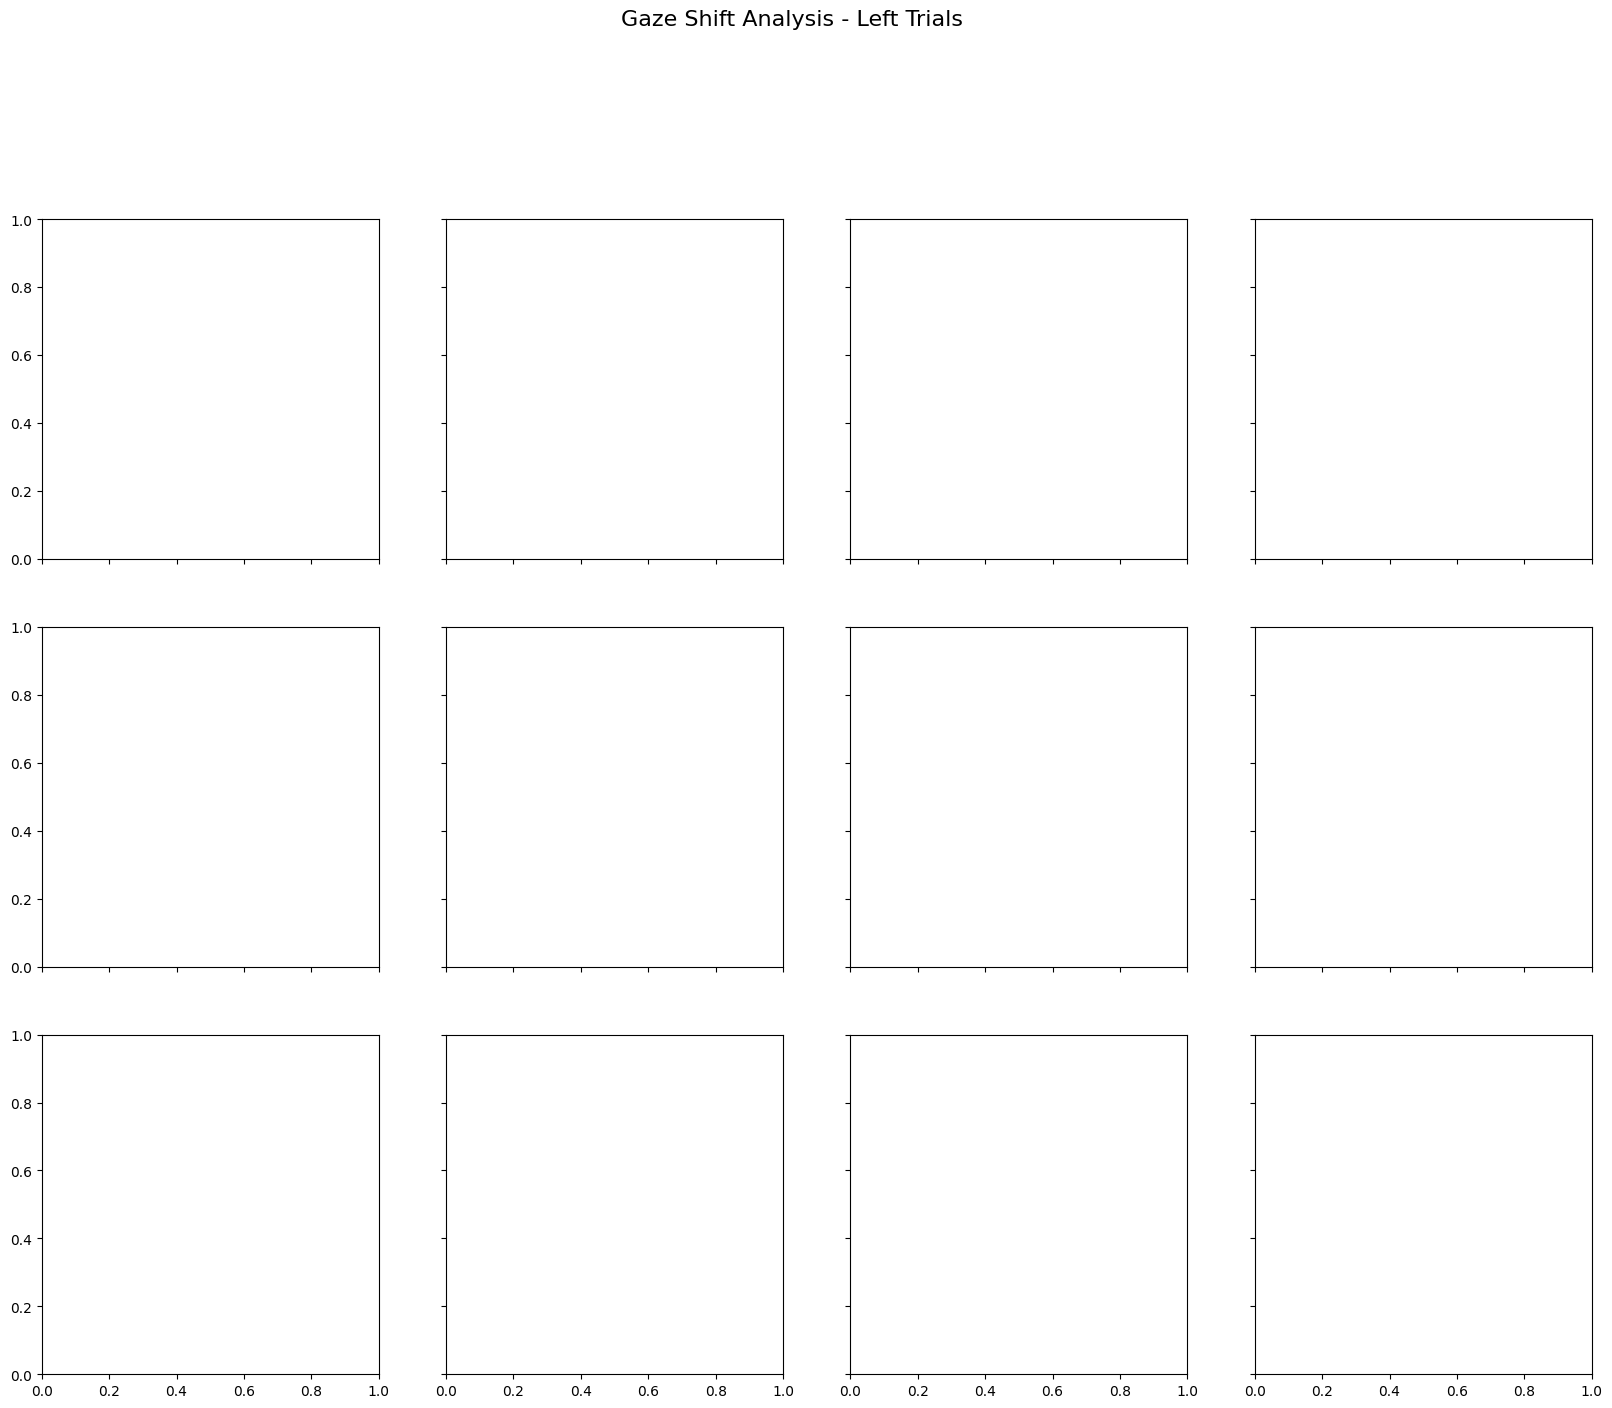

In [149]:
def plot_gaze_shifts_grid(tracking_df, gaze_df, imu_df):
    """
    Create comprehensive grid plots of gaze shifts
    
    Parameters:
    - tracking_df: DataFrame with tracking data
    - gaze_df: DataFrame with gaze data  
    - imu_df: DataFrame with IMU data (one row per experiment)
    """
    # Define cluster parameters
    obstacle_clusters = [0, 1, 2]
    gaze_clusters = [0, 1, 2, 3]
    directions = ['left', 'right']
    cluster_colors = {0: 'red', 1: 'blue', 2: 'green', 3: 'purple'}
    
    # Create figures for each direction
    for direction in directions:
        # Prepare figure
        fig, axs = plt.subplots(len(obstacle_clusters), len(gaze_clusters), 
                               figsize=(20, 15),
                               sharex=True, sharey=True)
        fig.suptitle(f'Gaze Shift Analysis - {direction.capitalize()} Trials', y=1.02, fontsize=16)
        
        # Initialize empty lists to store plot data for each subplot
        plot_data = {}
        for obst_clust in obstacle_clusters:
            for gaze_clust in gaze_clusters:
                plot_data[(obst_clust, gaze_clust)] = {'x': [], 'y': []}
        
        # Process each experiment from IMU data
        for _, imu_row in imu_df.iterrows():
            animal = imu_row['animal']
            date = imu_row['date']
            imu_correct_timestamp = imu_row['Openephys_time'][0]
            
            # Subset the data for this experiment
            curr_tracking = tracking_df[(tracking_df['animal'] == animal) & 
                                      (tracking_df['date'] == date)]
            curr_gaze = gaze_df[(gaze_df['animal'] == animal) & 
                              (gaze_df['date'] == date)]
            
            if len(curr_tracking) == 0 or len(curr_gaze) == 0:
                continue
            
            # Process each obstacle cluster and gaze cluster combination
            for obst_clust in obstacle_clusters:
                # Filter tracking data for current obstacle cluster and direction
                curr_obst_tracking = curr_tracking[(curr_tracking['obstacle_cluster'] == obst_clust) &
                                                 (curr_tracking['odd'] == direction)]
                
                if len(curr_obst_tracking) == 0:
                    continue
                
                for gaze_clust in gaze_clusters:
                    # Filter gaze data for current gaze cluster
                    curr_gaze_clust = curr_gaze[curr_gaze['cluster'] == gaze_clust]
                    if len(curr_gaze_clust) == 0:
                        continue
                    
                    # Process trials and collect data
                    print('imu',imu_correct_timestamp)
                    print(animal,date,gaze_clust)
                    print('ts',curr_gaze_clust['gaze_timestamp'].to_numpy()[2])
                    process_experiment_data(curr_obst_tracking, curr_gaze_clust, 
                                          imu_correct_timestamp, 
                                          plot_data[(obst_clust, gaze_clust)])
        
        # Create all subplots after collecting all data
        for row_idx, obst_clust in enumerate(obstacle_clusters):
            for col_idx, gaze_clust in enumerate(gaze_clusters):
                ax = axs[row_idx, col_idx]
                
                # Plot arena and obstacle (using first trial as template)
                plot_arena(tracking_df.iloc[0], axis=ax)
                plot_orginal_obstacle(tracking_df.iloc[0], axis=ax, cluster=obst_clust)
                
                # Plot trajectories and gaze points
                data = plot_data[(obst_clust, gaze_clust)]
                if data['x']:
                    # Plot all trajectories
                    for x, y in zip(data['x'], data['y']):
                        ax.plot(x, y, alpha=0.1, color='gray', linewidth=0.5)
                    
                    # Plot all gaze points
                    ax.scatter([x for traj in data['x'] for x in traj],
                              [y for traj in data['y'] for y in traj],
                              color=cluster_colors[gaze_clust],
                              alpha=0.6,
                              s=20)
                
                ax.set_title(f'Obstacle {obst_clust}, Gaze {gaze_clust}', pad=10)
        
        plt.tight_layout()
        plt.show()

def process_experiment_data(trial_df, gaze_df, imu_correct_timestamp, output_dict):
    """Process data for one experiment and collect plot data"""
    
    gaze_timestmps = gaze_df['gaze_timestamp'].to_numpy()
    
    for _, row in trial_df.iterrows():
        # Store trajectory data
        output_dict['x'].append(row.ts_head_cen_x_cm)
        output_dict['y'].append(row.ts_head_cen_y_cm)
        print('ts2',gaze_timestmps[1])
        #print(row.ts_trial_timestamps - imu_correct_timestamp, 
        #    gaze_timestmps)
        # Find matching gaze frames
        trial_gaze_idx, _ = find_event_frames(
            row.ts_trial_timestamps - imu_correct_timestamp, 
            gaze_timestmps
        )
        print(trial_gaze_idx)
        # Store matching gaze points
        for gaze_idx in trial_gaze_idx:
            gaze_row = gaze_df.iloc[gaze_idx]
            _, trial_pt_idx = find_event_frames(
                row.ts_trial_timestamps - imu_correct_timestamp,
                np.array([gaze_row.gaze_timestamp])
            )
            
            if len(trial_pt_idx) > 0:
                output_dict['x'].append(row.ts_head_cen_x_cm[trial_pt_idx[0]])
                output_dict['y'].append(row.ts_head_cen_y_cm[trial_pt_idx[0]])

# Example usage:
plot_gaze_shifts_grid(
    tracking_df=F3LILT_TT_df,
    gaze_df=F3LILT_TT_gaze_df,
    imu_df=F3LILT_TT_imu_df
)

In [128]:
F3LILT_TT_imu_df['Openephys_time']

0    [46572.788723, 46572.788787, 46572.788825, 465...
1    [52206.180198, 52206.180275, 52206.180339, 522...
2    [52151.789568, 52151.78967, 52151.789708, 5215...
3    [50320.705382, 50320.705459, 50320.70551, 5032...
4    [59571.872563, 59571.872665, 59571.872742, 595...
5    [51811.089612, 51811.089676, 51811.089702, 518...
6    [54548.926336, 54548.926412, 54548.926451, 545...
7    [49347.797657, 49347.797734, 49347.797772, 493...
8    [63054.55168, 63054.551731, 63054.551769, 6305...
9    [57154.857369, 57154.857446, 57154.857497, 571...
Name: Openephys_time, dtype: object

In [98]:
row.ts_trial_timestamps

array([48058.378368, 48058.394995, 48058.411712, 48058.428403,
       48058.445056, 48058.461734, 48058.478822, 48058.495091,
       48058.511756, 48058.528422, 48058.545113, 48058.561766,
       48058.578457, 48058.595072, 48058.611763, 48058.628556,
       48058.645132, 48058.661836, 48058.678502, 48058.695244,
       48058.711897, 48058.728524, 48058.745216, 48058.761881,
       48058.778585, 48058.795315, 48058.811904, 48058.828595,
       48058.845427, 48058.861913, 48058.87863, 48058.895641,
       48058.911974, 48058.928934, 48058.945715, 48058.962022,
       48058.978726, 48058.995392, 48059.01198, 48059.028659,
       48059.045683, 48059.062016, 48059.078745, 48059.095436,
       48059.112064, 48059.128742, 48059.14542, 48059.162419,
       48059.178764, 48059.195417, 48059.21216, 48059.228787,
       48059.245491, 48059.262105, 48059.278822, 48059.295449,
       48059.312166, 48059.328857, 48059.345548, 48059.362214,
       48059.378905, 48059.395584, 48059.412377, 48059.4290

In [ ]:
curr_obst_tracking, curr_gaze_clust, 
                                      imu_correct_timestamp, 
                                      plot_data[(obst_clust, gaze_clust)]

TypeError: 'float' object is not iterable

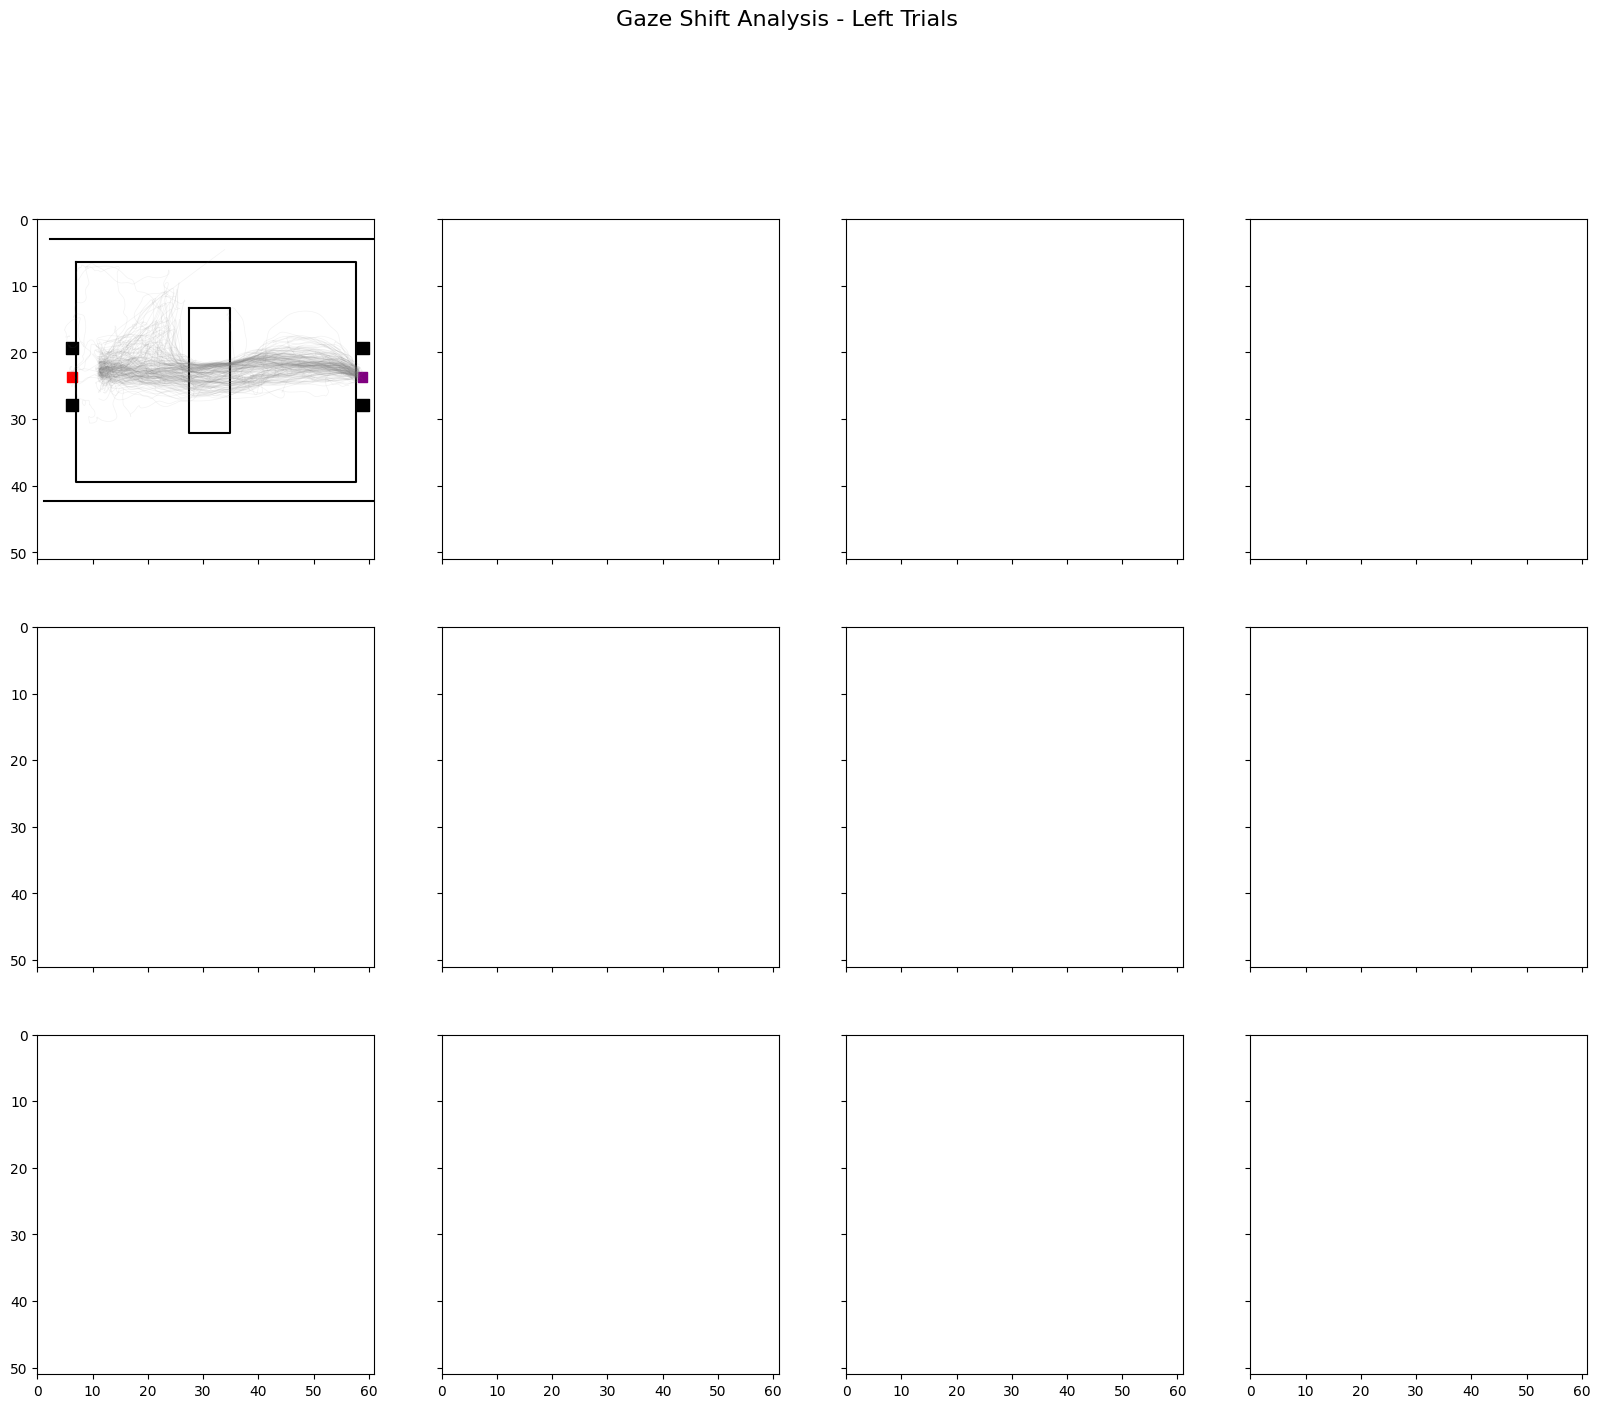

In [ ]:
def plot_gaze_shifts_grid(tracking_df, gaze_df, imu_df):
    """
    Create comprehensive grid plots of gaze shifts
    
    Parameters:
    - tracking_df: DataFrame with tracking data
    - gaze_df: DataFrame with gaze data  
    - imu_df: DataFrame with IMU data (one row per experiment)
    """
    # Define cluster parameters
    obstacle_clusters = [0, 1, 2]
    gaze_clusters = [0, 1, 2, 3]
    directions = ['left', 'right']
    cluster_colors = {0: 'red', 1: 'blue', 2: 'green', 3: 'purple'}
    
    # Create figures for each direction
    for direction in directions:
        # Prepare figure
        fig, axs = plt.subplots(len(obstacle_clusters), len(gaze_clusters), 
                               figsize=(20, 15),
                               sharex=True, sharey=True)
        fig.suptitle(f'Gaze Shift Analysis - {direction.capitalize()} Trials', y=1.02, fontsize=16)
        
        # Initialize empty lists to store plot data for each subplot
        plot_data = {}
        for obst_clust in obstacle_clusters:
            for gaze_clust in gaze_clusters:
                plot_data[(obst_clust, gaze_clust)] = {'x': [], 'y': []}
        
        # Process each experiment from IMU data
        for _, imu_row in imu_df.iterrows():
            animal = imu_row['animal']
            date = imu_row['date']
            imu_correct_timestamp = imu_row['Openephys_time'][0]
            
            # Subset the data for this experiment
            curr_tracking = tracking_df[(tracking_df['animal'] == animal) & 
                                      (tracking_df['date'] == date)]
            curr_gaze = gaze_df[(gaze_df['animal'] == animal) & 
                              (gaze_df['date'] == date)]
            
            if len(curr_tracking) == 0 or len(curr_gaze) == 0:
                continue
            
            # Process each obstacle cluster and gaze cluster combination
            for obst_clust in obstacle_clusters:
                # Filter tracking data for current obstacle cluster and direction
                curr_obst_tracking = curr_tracking[(curr_tracking['obstacle_cluster'] == obst_clust) &
                                                 (curr_tracking['odd'] == direction)]
                
                if len(curr_obst_tracking) == 0:
                    continue
                
                for gaze_clust in gaze_clusters:
                    # Filter gaze data for current gaze cluster
                    curr_gaze_clust = curr_gaze[curr_gaze['cluster'] == gaze_clust]
                    if len(curr_gaze_clust) == 0:
                        continue
                    
                    # Process trials and collect data
                    process_experiment_data(curr_obst_tracking, curr_gaze_clust, 
                                          imu_correct_timestamp, 
                                          plot_data[(obst_clust, gaze_clust)])
        
        # Create all subplots after collecting all data
        for row_idx, obst_clust in enumerate(obstacle_clusters):
            for col_idx, gaze_clust in enumerate(gaze_clusters):
                ax = axs[row_idx, col_idx]
                
                # Plot arena and obstacle (using first trial as template)
                plot_arena(curr_tracking, axis=ax)
                #print(tracking_df.obstacle_cluster.unique())
                plot_orginal_obstacle(curr_tracking, axis=ax, cluster=obst_clust)
                
                # Plot trajectories and gaze points
                data = plot_data[(obst_clust, gaze_clust)]
                if data['x']:
                    # Plot all trajectories
                    for x, y in zip(data['x'], data['y']):
                        ax.plot(x, y, alpha=0.1, color='gray', linewidth=0.5)
                    
                    # Plot all gaze points
                    ax.scatter([x for traj in data['x'] for x in traj],
                              [y for traj in data['y'] for y in traj],
                              color=cluster_colors[gaze_clust],
                              alpha=0.6,
                              s=20)
                
                ax.set_title(f'Obstacle {obst_clust}, Gaze {gaze_clust}', pad=10)
        
        plt.tight_layout()
        plt.show()

def process_experiment_data(trial_df, gaze_df, imu_correct_timestamp, output_dict):
    """Process data for one experiment and collect plot data"""
    gaze_timestmps = gaze_df['gaze_timestamp'].to_numpy()
    
    for _, row in trial_df.iterrows():
        # Store trajectory data
        output_dict['x'].append(row.ts_head_cen_x_cm)
        output_dict['y'].append(row.ts_head_cen_y_cm)
        #print(row.ts_trial_timestamps - imu_correct_timestamp, 
        #    gaze_timestmps)
        # Find matching gaze frames
        trial_gaze_idx, _ = find_event_frames(
            row.ts_trial_timestamps - imu_correct_timestamp, 
            gaze_timestmps
        )
       
        if trial_gaze_idx == None:
            continue
        # Store matching gaze points
        else:
            for gaze_idx in trial_gaze_idx:
                gaze_row = gaze_df.iloc[gaze_idx]
                _, trial_pt_idx = find_event_frames(
                    row.ts_trial_timestamps - imu_correct_timestamp,
                    np.array([gaze_row.gaze_timestamp])
                )

                if len(trial_pt_idx) > 0:
                    output_dict['x'].append(row.ts_head_cen_x_cm[trial_pt_idx[0]])
                    output_dict['y'].append(row.ts_head_cen_y_cm[trial_pt_idx[0]])

# Example usage:
plot_gaze_shifts_grid(
    tracking_df=F3LILT_TT_df,
    gaze_df=F3LILT_TT_gaze_df,
    imu_df=F3LILT_TT_imu_df
)

In [175]:
def calculate_vector_between_points(point1, point2):
    """
    Calculate the vector between two (x, y) points.

    Args:
        point1 (tuple or list): The coordinates of the first point (x1, y1).
        point2 (tuple or list): The coordinates of the second point (x2, y2).

    Returns:
        np.ndarray: The vector as a NumPy array [dx, dy].
    """
    x1, y1 = point1
    x2, y2 = point2
    
    dx = x2 - x1
    dy = y2 - y1

    
    vector = np.array([dx, dy])
    
    return vector


def angle_between_vectors(vector1, vector2):
    # Convert input lists to NumPy arrays for vector operations
    vector1 = np.array(vector1)
    vector2 = np.array(vector2)
    
    # Calculate the dot product of the two vectors
    dot_product = np.dot(vector1, vector2)
    
    # Calculate the magnitudes (norms) of each vector
    magnitude1 = np.linalg.norm(vector1)
    magnitude2 = np.linalg.norm(vector2)
    
    # Calculate the cosine of the angle between the vectors
    cosine_angle = dot_product / (magnitude1 * magnitude2)
    
    # Use arccosine to calculate the angle in radians
    angle_radians = np.arccos(cosine_angle)
    
    # Calculate the angle in degrees
    angle_degrees = np.degrees(angle_radians)
    return angle_radians, angle_degrees

In [267]:
def create_df_by_type_oa_cams(df):
    '''creates df of long short middle approaches'''
    cluster_0_long = df[(df['obstacle_cluster']==0)&(df['start']=='top')]
    cluster_2_long = df[(df['obstacle_cluster']==2)&(df['start']=='bottom')]
   

    
    

    long_df = pd.concat([cluster_0_long,cluster_2_long])
    
    return long_df

In [268]:
def start(df):
    labels = ['top','bottom']
    top_bottom = split_range_into_parts(np.nanmedian(pd.unique(df.arenaTL_T_y_cm)),np.nanmedian(pd.unique(df.arenaBL_T_y_cm)),2)
    top_bottom_dict = dict(zip(labels,top_bottom))
    for ind, row in df.iterrows():
        if top_bottom_dict.get('top')[0]<= np.nanmean(row['ts_head_cen_y_cm'][:20]) <= top_bottom_dict.get('top')[1]:
            df.at[ind,'start'] = 'top'
        if top_bottom_dict.get('bottom')[0]<= np.nanmean(row['ts_head_cen_y_cm'][:20]) <= top_bottom_dict.get('bottom')[1]:
            df.at[ind,'start'] = 'bottom'
        if np.nanmean(row['ts_head_cen_y_cm'][:5]) == np.nan:
            df.drop(df.iloc[ind])
    df = df[df['start'].notna()]

In [180]:
F3LILT_TT_df.ts_rightear_x_cm

0      [54.390169457910744, 54.371577769828555, 54.33...
1      [9.948800063381594, 9.974497439915108, 10.0243...
2      [55.19115554295208, 55.16398318782464, 55.1117...
3      [10.075883913965821, 10.094993849352646, 10.13...
4      [54.76779095983384, 54.745203334330434, 54.699...
                             ...                        
873    [54.9543279870138, 54.92744441992052, 54.87555...
874    [10.12312249941057, 10.14524834170247, 10.1871...
875    [55.115946742364244, 55.11632682571057, 55.116...
876    [10.399943536425166, 10.405368957022484, 10.41...
877    [54.97831279884998, 54.96951525620918, 54.9531...
Name: ts_rightear_x_cm, Length: 878, dtype: object

In [186]:
ts_angle_to_open_corner(F3LILT_TT_df)

In [320]:
lateral_error_open_corner(F3LILT_TT_df)

In [206]:
list_columns(F3LILT_TT_df,['arena'])

array(['arenaTL_T_x', 'arenaTL_T_y', 'arenaTL_T_likelihood',
       'arenaTR_T_x', 'arenaTR_T_y', 'arenaTR_T_likelihood',
       'arenaBL_T_x', 'arenaBL_T_y', 'arenaBL_T_likelihood',
       'arenaBR_T_x', 'arenaBR_T_y', 'arenaBR_T_likelihood',
       'arenaTL_B_x', 'arenaTL_B_y', 'arenaTL_B_likelihood',
       'arenaTR_B_x', 'arenaTR_B_y', 'arenaTR_B_likelihood',
       'arenaBL_B_x', 'arenaBL_B_y', 'arenaBL_B_likelihood',
       'arenaBR_B_x', 'arenaBR_B_y', 'arenaBR_B_likelihood',
       'arenaTL_T_x_cm', 'arenaTL_T_y_cm', 'arenaTR_T_x_cm',
       'arenaTR_T_y_cm', 'arenaBL_T_x_cm', 'arenaBL_T_y_cm',
       'arenaBR_T_x_cm', 'arenaBR_T_y_cm', 'arenaTL_B_x_cm',
       'arenaTL_B_y_cm', 'arenaTR_B_x_cm', 'arenaTR_B_y_cm',
       'arenaBL_B_x_cm', 'arenaBL_B_y_cm', 'arenaBR_B_x_cm',
       'arenaBR_B_y_cm'], dtype='<U20')

In [322]:
start(F3LILT_TT_df)
long= create_df_by_type_oa_cams(F3LILT_TT_df)

In [191]:
ts_calculate_relative_distance(F3LILT_TT_df)

In [195]:
deveation(F3LILT_TT_df)

In [192]:
def first_occurrence_indices(arr):
    unique_values, first_indices = np.unique(arr, return_index=True)
    sorted_indices = np.sort(first_indices)
    return sorted_indices

In [194]:
def deveation(df):
    for ind,row in df.iterrows():
        try:
            obstacle_ind = int(np.argwhere(row.ts_distance_from_edge>= -2).max())
        except ValueError:
            continue
        try:
            goal_ind = int(np.argwhere(row.ts_distance_from_edge<= -2).min())
        except ValueError:
            continue
        df.at[ind,'obstacle_ind'] = obstacle_ind
        df.at[ind,'goal_ind'] = goal_ind

        obstacle_basis_start_x, obstacle_basis_start_y = row.ts_head_cen_x_cm[0],row.ts_head_cen_y_cm[0]
        obstacle_basis_end_x, obstacle_basis_end_y = row.ts_head_cen_x_cm[obstacle_ind],row.ts_head_cen_y_cm[obstacle_ind]
        obstacle_basis_vector = calculate_vector_between_points((obstacle_basis_start_x,obstacle_basis_start_y),(obstacle_basis_end_x,obstacle_basis_end_y))
        obstacle_head_cen_x,obstacle_head_cen_y = row.ts_head_cen_x_cm[:obstacle_ind],row.ts_head_cen_y_cm[:obstacle_ind]
        df.at[ind,'obstacle_head_cen_x'] = obstacle_head_cen_x.astype(object)
        df.at[ind,'obstacle_head_cen_y'] = obstacle_head_cen_y.astype(object)
        df.at[ind,'obstacle_basis_start_x'] = obstacle_basis_start_x
        df.at[ind,'obstacle_basis_start_y'] = obstacle_basis_start_y
        df.at[ind,'obstacle_basis_end_x'] = obstacle_basis_end_x
        df.at[ind,'obstacle_basis_end_y'] = obstacle_basis_end_y


        goal_basis_start_x, goal_basis_start_y = row.ts_head_cen_x_cm[goal_ind],row.ts_head_cen_y_cm[goal_ind]
        goal_basis_end_x, goal_basis_end_y = row.ts_head_cen_x_cm[-1],row.ts_head_cen_y_cm[-1]
        goal_basis_vector = calculate_vector_between_points((goal_basis_start_x,goal_basis_start_y),(goal_basis_end_x,goal_basis_end_y))
        goal_head_cen_x,goal_head_cen_y = row.ts_head_cen_x_cm[goal_ind:],row.ts_head_cen_y_cm[goal_ind:]
        df.at[ind,'goal_head_cen_x'] = goal_head_cen_x.astype(object)
        df.at[ind,'goal_head_cen_y'] = goal_head_cen_y.astype(object)
        df.at[ind,'goal_basis_start_x'] = goal_basis_start_x
        df.at[ind,'goal_basis_start_y'] = goal_basis_start_y
        df.at[ind,'goal_basis_end_x'] = goal_basis_end_x
        df.at[ind,'goal_basis_end_y'] = goal_basis_end_y

        obstacle_devations = []
        for i in list(range(len(obstacle_head_cen_x))):
            obstacle_head_cen_vector = calculate_vector_between_points((obstacle_basis_start_x,obstacle_basis_start_y),(obstacle_head_cen_x[i],obstacle_head_cen_y[i]))
            _,dev = angle_between_vectors(obstacle_head_cen_vector,obstacle_basis_vector)
            #devations.append(dev) 
            #dev = calculate_angle((head_cen_x[i],head_cen_y[i]),(origin_x,origin_y),(end_x,end_y))
            obstacle_devations.append(dev)
        df.at[ind,'obstacle_devations'] = np.array(obstacle_devations).astype(object)
        
        goal_devations = []
        for i in list(range(len(goal_head_cen_x))):
            goal_head_cen_vector = calculate_vector_between_points((goal_basis_start_x,goal_basis_start_y),(goal_head_cen_x[i],goal_head_cen_y[i]))
            _,dev = angle_between_vectors(goal_head_cen_vector,goal_basis_vector)
            #devations.append(dev) 
            #dev = calculate_angle((head_cen_x[i],head_cen_y[i]),(origin_x,origin_y),(end_x,end_y))
            goal_devations.append(dev)
        df.at[ind,'goal_devations'] = np.array(goal_devations).astype(object)


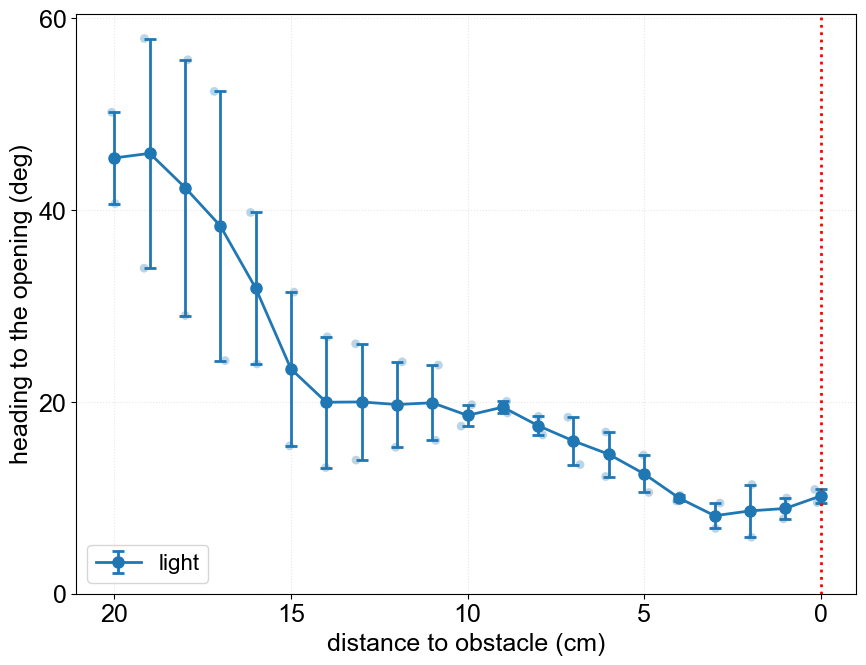

In [292]:
# Set font parameters to match previous plots
font = {'family': 'arial',
        
        'size': 18}
plt.rc('font', **font)

xnew = np.arange(0, 21, 1)
xnew = np.flip(xnew)
fig, ax = plt.subplots(layout='tight', figsize=(9,7))

ax.invert_xaxis()
data = pd.concat([long])
data = data[(data.obstacle_cluster == 0)|(data.obstacle_cluster == 2)]
data = drop_nans_in_columns(data, 'obstacle_ind')

# Storage for data
light_medians = []
dark_medians = []
light_scatter = []  # For individual animal points
dark_scatter = []   # For individual animal points

for task, task_df in data.groupby(['task']):
    # Process each animal
    for animal, animal_df in task_df.groupby(['animal']):
        angle_array = np.empty([animal_df.shape[0], len(xnew)])
        angle_array[:] = np.nan
        
        for i, row in enumerate(animal_df.iterrows()):
            x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
            x1 = x[first_occurrence_indices(np.round(x))]
            y = row[1]['ts_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
            y1 = y[first_occurrence_indices(np.round(x))]
            
            if sum(y) != 0:
                interpolater = interp1d(x1, y1, bounds_error=False)
                angle_array[i] = interpolater(xnew)
        
        animal_median = np.nanmedian(angle_array, axis=0)
        
        # Add jitter to x positions
        x_jittered = xnew + np.random.uniform(-0.2, 0.2, size=len(xnew))
        
        if task == 'oa':
            light_medians.append(animal_median)
            light_scatter.append((x_jittered, animal_median))
        else:
            dark_medians.append(animal_median)
            dark_scatter.append((x_jittered, animal_median))

# Calculate population statistics
light_medians = np.array(light_medians)
dark_medians = np.array(dark_medians)

light_angle_median = np.nanmedian(light_medians, axis=0)
dark_angle_median = np.nanmedian(dark_medians, axis=0)

light_sd = np.nanstd(light_medians, axis=0)
dark_sd = np.nanstd(dark_medians, axis=0)

# Plot individual points first (so they're behind)
for x_jittered, y in light_scatter:
    ax.scatter(x_jittered, y, color='tab:blue', alpha=0.3, s=40, edgecolors='none')
for x_jittered, y in dark_scatter:
    ax.scatter(x_jittered, y, color='black', alpha=0.3, s=40, edgecolors='none')

# Plot mean lines with error bars
ax.errorbar(xnew, light_angle_median, yerr=light_sd, 
           fmt='-', color='tab:blue', linewidth=2, 
           marker='o', markersize=8, capsize=4, capthick=2,
           label='light')


# Formatting to match previous plots
ax.set_xticks([20,15,10,5,0])
ax.set_yticks([0,20,40,60])
ax.set_ylabel('heading to the opening (deg)', fontsize=18)
ax.set_xlabel('distance to obstacle (cm)', fontsize=18)
ax.axvline(0, color='r', ls=':', linewidth=2)

# Legend with matching style
ax.legend(loc='lower left', fontsize=16, framealpha=0.8)

# Grid lines for readability
ax.grid(True, linestyle=':', alpha=0.3)

plt.tight_layout()
plt.show()

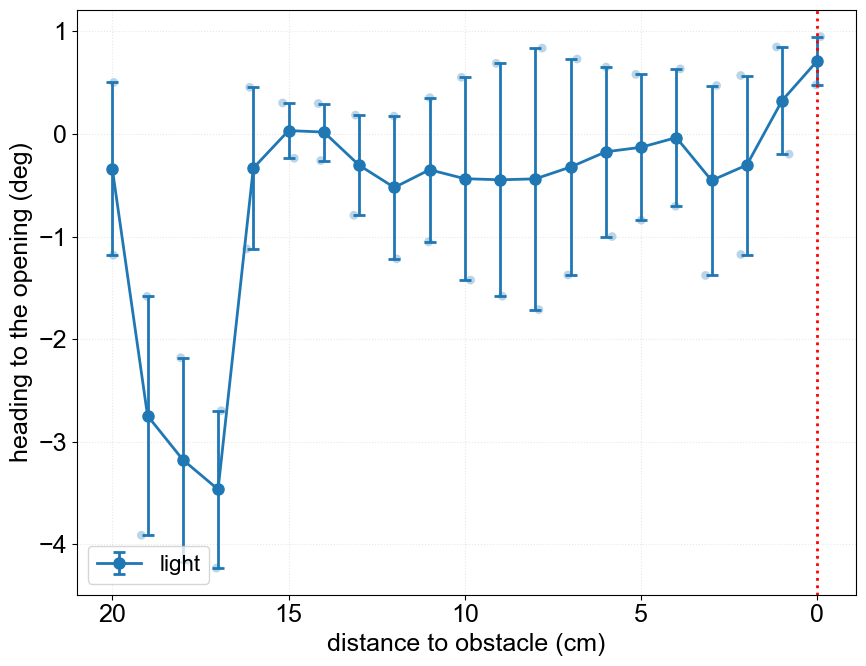

In [324]:
# Set font parameters to match previous plots
font = {'family': 'arial',
        
        'size': 18}
plt.rc('font', **font)

xnew = np.arange(0, 21, 1)
xnew = np.flip(xnew)
fig, ax = plt.subplots(layout='tight', figsize=(9,7))

ax.invert_xaxis()
data = pd.concat([long])
data = data[(data.obstacle_cluster == 0)|(data.obstacle_cluster == 2)]
data = drop_nans_in_columns(data, 'obstacle_ind')

# Storage for data
light_medians = []
dark_medians = []
light_scatter = []  # For individual animal points
dark_scatter = []   # For individual animal points

for task, task_df in data.groupby(['task']):
    # Process each animal
    for animal, animal_df in task_df.groupby(['animal']):
        angle_array = np.empty([animal_df.shape[0], len(xnew)])
        angle_array[:] = np.nan
        
        for i, row in enumerate(animal_df.iterrows()):
            x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
            x1 = x[first_occurrence_indices(np.round(x))]
            y = row[1]['lateral_error'][:int(row[1]['obstacle_ind'])].astype(float)
            y1 = y[first_occurrence_indices(np.round(x))]
            
            if sum(y) != 0:
                interpolater = interp1d(x1, y1, bounds_error=False)
                angle_array[i] = interpolater(xnew)
        
        animal_median = np.nanmedian(angle_array, axis=0)
        
        # Add jitter to x positions
        x_jittered = xnew + np.random.uniform(-0.2, 0.2, size=len(xnew))
        
        if task == 'oa':
            light_medians.append(animal_median)
            light_scatter.append((x_jittered, animal_median))
        else:
            dark_medians.append(animal_median)
            dark_scatter.append((x_jittered, animal_median))

# Calculate population statistics
light_medians = np.array(light_medians)
dark_medians = np.array(dark_medians)

light_angle_median = np.nanmedian(light_medians, axis=0)
dark_angle_median = np.nanmedian(dark_medians, axis=0)

light_sd = np.nanstd(light_medians, axis=0)
dark_sd = np.nanstd(dark_medians, axis=0)

# Plot individual points first (so they're behind)
for x_jittered, y in light_scatter:
    ax.scatter(x_jittered, y, color='tab:blue', alpha=0.3, s=40, edgecolors='none')
for x_jittered, y in dark_scatter:
    ax.scatter(x_jittered, y, color='black', alpha=0.3, s=40, edgecolors='none')

# Plot mean lines with error bars
ax.errorbar(xnew, light_angle_median, yerr=light_sd, 
           fmt='-', color='tab:blue', linewidth=2, 
           marker='o', markersize=8, capsize=4, capthick=2,
           label='light')


# Formatting to match previous plots
ax.set_xticks([20,15,10,5,0])
#ax.set_yticks([0,20,40,60])
ax.set_ylabel('heading to the opening (deg)', fontsize=18)
ax.set_xlabel('distance to obstacle (cm)', fontsize=18)
ax.axvline(0, color='r', ls=':', linewidth=2)

# Legend with matching style
ax.legend(loc='lower left', fontsize=16, framealpha=0.8)

# Grid lines for readability
ax.grid(True, linestyle=':', alpha=0.3)

plt.tight_layout()
plt.show()

In [213]:
def correct_trace(row,ob_x,ob_y):
    input_ob_x, input_ob_y = row.gt_obstacleTL_x_cm ,row.gt_obstacleTL_y_cm
    direction = row.odd
    diff_x = input_ob_x - ob_x[0]
    diff_y = input_ob_y- ob_y[0]
    correct_y = 1*(diff_y)
    if direction == 'right':
        correct_x = -1*(diff_x)

    else:
        correct_x = diff_x
    return smooth(row.ts_head_cen_x_cm - diff_x) , smooth(row.ts_head_cen_y_cm- diff_y) 

In [229]:
ind

437

2


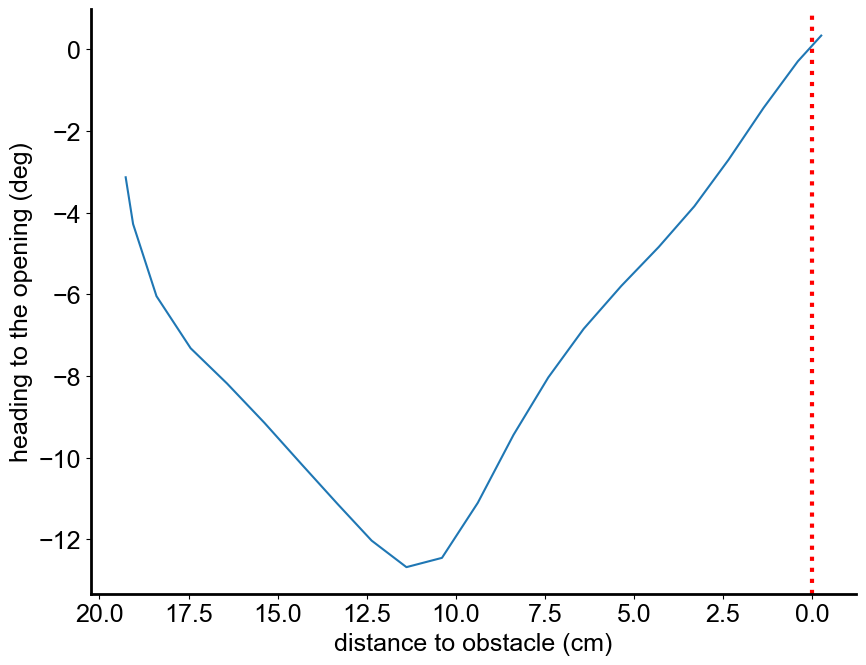

In [353]:
fig,ax = plt.subplots(1,1,figsize=(9,7), layout = 'tight')
sample_light = long.sample(1)
for ind,row in sample_light.iterrows():
    x = row['ts_distance_from_edge'][:int(row['obstacle_ind'])].astype(float)
    x1 = x[first_occurrence_indices(np.round(x))]
    y = row['lateral_error'][:int(row['obstacle_ind'])].astype(float)
    y1 = y[first_occurrence_indices(np.round(x))]
ax.set_xlabel('distance to obstacle (cm)')
ax.set_ylabel('heading to the opening (deg)')
ax.plot(smooth(x1),smooth(y1))
ax.invert_xaxis()
ax.axvline(0, color='r', ls=':',linewidth = 3)
#ax.text(0, ax.get_ylim()[1]/2,'obstacle edge', color='r', ha='right', va='center', rotation=90,fontsize=20)
ax.spines[['right', 'top']].set_visible(False)
ax.spines[['left', 'bottom']].set_linewidth(2)
print(row.obstacle_cluster)

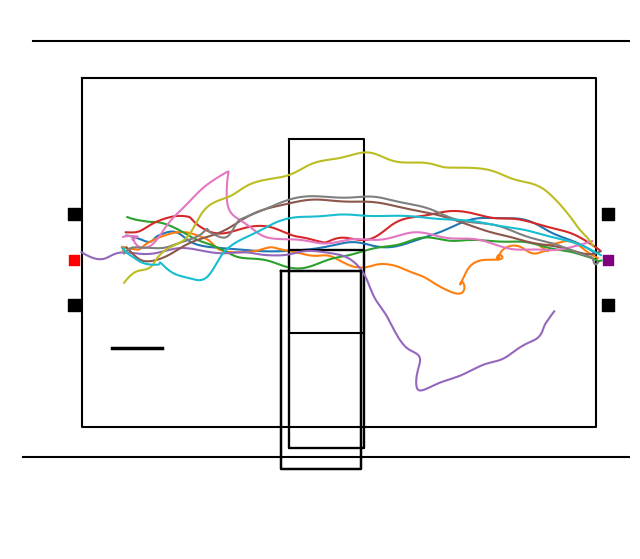

In [459]:


plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42  
data = long[(long.obstacle_cluster == 2) |(long.odd == 'left')]
sample = data.sample(10)
fig,ax = plt.subplots(1,1,figsize=(8,7))
plot_arena(sample,ax)
plot_orginal_obstacle(sample,ax,0)

for ind,row in sample.iterrows():
    
    #ax[1].set_xlim(20,0)
    


    ax.set_xticks([])
    ax.set_yticks([])
  
    #ax[2].invert_xaxis()
    ob_x,ob_y = plot_orginal_obstacle(data,ax,int(row.obstacle_cluster))



    ax.plot(row.ts_head_cen_x_cm,row.ts_head_cen_y_cm)

    
       
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.plot((10,15),(32,32),c ='black', linewidth = 2.5)

In [190]:
def calculate_distances(x_points, y_points, x_reference, y_reference):
    """
    Calculate the distances of a set of (x, y) points from a reference point.

    Args:
        x_points (array-like): Array of x-coordinates of the points.
        y_points (array-like): Array of y-coordinates of the points.
        x_reference (float): The x-coordinate of the reference point.
        y_reference (float): The y-coordinate of the reference point.

    Returns:
        list: List of distances from the reference point to each point in the set.
    """
    # Convert input arrays to NumPy arrays
    x_points = np.array(x_points)
    y_points = np.array(y_points)

    # Calculate the distances
    distances = np.sqrt((x_points - x_reference)**2 + (y_points - y_reference)**2)

    return distances


def ts_calculate_relative_distance(df):
    """calculates relavtive distance of nose to point on obstacle"""
    for direction, direction_frame in df.groupby(['odd']):
        for ind,row in direction_frame.iterrows():  
            if direction == 'right':
                try:
                    nose_x = row['ts_head_cen_x_cm']
                    nose_y = row['ts_head_cen_y_cm']
                    distances = []
                    distances = []
                    for i,e in enumerate(nose_x):
                        obstalce_x = np.mean([row['gt_obstacleTR_x_cm'],row['gt_obstacleBR_x_cm']]) 
                        if nose_y[i] > row['gt_obstacleTR_y_cm'] and nose_y[i] < row['gt_obstacleBR_y_cm'] :
                            obstalce_y = nose_y[i]
                            if nose_x[i] < obstalce_x:
                                distance = np.abs(calculate_distances(nose_x[i],nose_y[i],obstalce_x,obstalce_y)) * -1
                                distances.append(distance)
                            if nose_x[i] > obstalce_x:
                                distance = np.abs(calculate_distances(nose_x[i],nose_y[i],obstalce_x,obstalce_y)) 
                                distances.append(distance)
                            
                        else:
                            distance_to_top = np.abs(calculate_distances(nose_x[i],nose_y[i],obstalce_x,row['gt_obstacleTR_y_cm']))
                            distance_to_bottom = np.abs(calculate_distances(nose_x[i],nose_y[i],obstalce_x,row['gt_obstacleBR_y_cm']))
                            if distance_to_top < distance_to_bottom:
                                distance = distance_to_top
                                if nose_x[i] < obstalce_x:
                                    distance = distance * -1
                                    distances.append(distance)
                                if nose_x[i] > obstalce_x:
                                    distance = distance 
                                    distances.append(distance)
                            if distance_to_top > distance_to_bottom:
                                distance = distance_to_bottom
                                if nose_x[i] < obstalce_x:
                                    distance = distance * -1
                                    distances.append(distance)
                                if nose_x[i] > obstalce_x:
                                    distance = distance 
                                    distances.append(distance)
                except IndexError:
                    distances.append(np.nan)

                
                df.at[ind,'ts_distance_from_edge'] = np.array(distances).astype(object)
                df.at[ind,'ts_len_distance_from_edge'] = np.array(distances).astype(object).size
            if direction =='left':
                try:
                    nose_x = row['ts_head_cen_x_cm']
                    nose_y = row['ts_head_cen_y_cm']
                    distances = []
                    distances = []
                    for i,e in enumerate(nose_x):
                        obstalce_x = np.mean([row['gt_obstacleTL_x_cm'],row['gt_obstacleBL_x_cm']]) 
                        if nose_y[i] > row['gt_obstacleTL_y_cm'] and nose_y[i] < row['gt_obstacleBL_y_cm']:
                            obstalce_y = nose_y[i]
                            if nose_x[i] > obstalce_x:
                                distance = np.abs(calculate_distances(nose_x[i],nose_y[i],obstalce_x,obstalce_y)) * -1
                                distances.append(distance)
                            if nose_x[i] < obstalce_x:
                                distance = np.abs(calculate_distances(nose_x[i],nose_y[i],obstalce_x,obstalce_y)) 
                                distances.append(distance)
                        else:
                            distance_to_top = np.abs(calculate_distances(nose_x[i],nose_y[i],obstalce_x,row['gt_obstacleTL_y_cm']))
                            distance_to_bottom = np.abs(calculate_distances(nose_x[i],nose_y[i],obstalce_x,row['gt_obstacleBL_y_cm']))
                            if distance_to_top < distance_to_bottom:
                                distance = distance_to_top
                                if nose_x[i] > obstalce_x:
                                    distance = distance * -1
                                    distances.append(distance)
                                if nose_x[i] < obstalce_x:
                                    distance = distance 
                                    distances.append(distance)
                            if distance_to_top > distance_to_bottom:
                                distance = distance_to_bottom
                                if nose_x[i] > obstalce_x:
                                    distance = distance * -1
                                    distances.append(distance)
                                if nose_x[i] < obstalce_x:
                                    distance = distance 
                                    distances.append(distance)
                except IndexError:
                    distances.append(np.nan)
            
                
                df.at[ind,'ts_distance_from_edge'] = np.array(distances).astype(object)
                df.at[ind,'ts_len_distance_from_edge'] = np.array(distances).astype(object).size

In [ ]:
def calculate_vector_between_points(point1, point2):
    """
    Calculate the vector between two (x, y) points.

    Args:
        point1 (tuple or list): The coordinates of the first point (x1, y1).
        point2 (tuple or list): The coordinates of the second point (x2, y2).

    Returns:
        np.ndarray: The vector as a NumPy array [dx, dy].
    """
    x1, y1 = point1
    x2, y2 = point2
    
    dx = x2 - x1
    dy = y2 - y1

    
    vector = np.array([dx, dy])
    
    return vector


def angle_between_vectors(vector1, vector2):
    # Convert input lists to NumPy arrays for vector operations
    vector1 = np.array(vector1)
    vector2 = np.array(vector2)
    
    # Calculate the dot product of the two vectors
    dot_product = np.dot(vector1, vector2)
    
    # Calculate the magnitudes (norms) of each vector
    magnitude1 = np.linalg.norm(vector1)
    magnitude2 = np.linalg.norm(vector2)
    
    # Calculate the cosine of the angle between the vectors
    cosine_angle = dot_product / (magnitude1 * magnitude2)
    
    # Use arccosine to calculate the angle in radians
    angle_radians = np.arccos(cosine_angle)
    
    # Calculate the angle in degrees
    angle_degrees = np.degrees(angle_radians)
    return angle_radians, angle_degrees

def ts_angle_to_open_corner(df):
    "for oa cams"
    """get angel of nose to open corner at a hold"""
    for direction, direction_frame in df.groupby(['odd']):
        for cluster, cluster_frame in direction_frame.groupby(['obstacle_cluster']):
            for ind,row in cluster_frame.iterrows():
                    nose_x = row['ts_head_cen_x_cm'].astype(float)
                    nose_y = row['ts_head_cen_y_cm'].astype(float)
                    ear_x = np.mean([row['ts_rightear_x_cm'],row['ts_leftear_x_cm']],axis=0)
                    ear_y = np.mean([row['ts_rightear_y_cm'],row['ts_leftear_y_cm']],axis=0)
                    
                    if direction == 'right':
                         if cluster == 0:
                               corner_x = row['gt_obstacleBR_x_cm']
                               corner_y = row['gt_obstacleBR_y_cm']+2
                               degs = []
                               
                               reye_degs = []
                               
                               leye_degs = []
   
                               body_degs = []
                               
                               
                               for i in list(range(len(nose_x))):
                                   vector1 = calculate_vector_between_points((ear_x[i],ear_y[i]),(nose_x[i],nose_y[i]))# vector from ear to nose
                                   vector2 = calculate_vector_between_points((ear_x[i],ear_y[i]),(corner_x,corner_y))# vector from nose to open corner
                                   rad,deg = angle_between_vectors(vector1,vector2)
                                   degs.append(deg)
                                   
                                   
   
                                   
                               degs = np.array(degs)
                               
                               
                           
                               #df.at[ind,'angle_to_corner_' + str()] = degs.astype(object)
                               try:
                                df.at[ind,'ts_angle_to_corner'] = degs.astype(object)
                                
                               except ValueError:
                                   print(degs)
                               except IndexError:
                                   df.at[ind,'ts_angle_to_corner'] = np.nan
                         if cluster == 1:
                                obstalce_edge= np.mean([row['gt_obstacleTR_x_cm'],row['gt_obstacleBR_x_cm']])
                                nose_near_edge = nose_x[np.nanargmin(np.abs(np.array(nose_x) - obstalce_edge))]
                                ind_nose_near_edge = np.argwhere(nose_x==nose_near_edge)[0][0]
                                distance_to_top = np.abs(calculate_distances(nose_x[ind_nose_near_edge],nose_y[ind_nose_near_edge],obstalce_edge,row['gt_obstacleTR_y_cm']))
                                distance_to_bottom = np.abs(calculate_distances(nose_x[ind_nose_near_edge],nose_y[ind_nose_near_edge],obstalce_edge,row['gt_obstacleBR_y_cm']))
                                if distance_to_top < distance_to_bottom:
                                    corner_x = row['gt_obstacleTR_x_cm']
                                    corner_y = row['gt_obstacleTR_y_cm']-2
                                    degs = []
                                    
                                    reye_degs = []
                                    
                                    leye_degs = []

                                    body_degs = []
                                    
                                    for i in list(range(len(nose_x))):
                                        vector1 = calculate_vector_between_points((ear_x[i],ear_y[i]),(nose_x[i],nose_y[i]))# vector from ear to nose
                                        vector2 = calculate_vector_between_points((ear_x[i],ear_y[i]),(corner_x,corner_y))# vector from nose to open corner
                                        rad,deg = angle_between_vectors(vector1,vector2)
                                        degs.append(deg)
                                        
                                    

                                        
                                    degs = np.array(degs)
                                    leye_degs = np.array(leye_degs)
                                    reye_degs = np.array(reye_degs)
                                    body_degs = np.array(body_degs)
                                    
                                if distance_to_top > distance_to_bottom:
                                    corner_x = row['gt_obstacleBR_x_cm']
                                    corner_y = row['gt_obstacleBR_y_cm']+2
                                    degs = []
                                    
                                    reye_degs = []
                                    
                                    leye_degs = []

                                    body_degs = []
                                    
                                    for i in list(range(len(nose_x))):
                                        vector1 = calculate_vector_between_points((ear_x[i],ear_y[i]),(nose_x[i],nose_y[i]))# vector from ear to nose
                                        vector2 = calculate_vector_between_points((ear_x[i],ear_y[i]),(corner_x,corner_y))# vector from nose to open corner
                                        rad,deg = angle_between_vectors(vector1,vector2)
                                        degs.append(deg)
                                        
                                    
                                        
                                    degs = np.array(degs)
                                    leye_degs = np.array(leye_degs)
                                    reye_degs = np.array(reye_degs)
                                    body_degs = np.array(body_degs)
                                    
                                #df.at[ind,'angle_to_corner_' + str()] = degs.astype(object)
                                try:
                                    df.at[ind,'ts_angle_to_corner'] = degs.astype(object)
                                    df.at[ind,'ts_leye_angle_to_corner'] = leye_degs.astype(object)
                                    df.at[ind,'ts_reye_angle_to_corner'] = reye_degs.astype(object)
                                    df.at[ind,'ts_body_angle_to_corner'] = body_degs.astype(object)
                                except IndexError:
                                    df.at[ind,'ts_angle_to_corner'] = np.nan
                                    df.at[ind,'ts_leye_angle_to_corner'] = np.nan
                                    df.at[ind,'ts_reye_angle_to_corner'] = np.nan
                                    df.at[ind,'ts_body_angle_to_corner'] = np.nan
                         if cluster == 2:
                            corner_x = row['gt_obstacleTR_x_cm']
                            corner_y = row['gt_obstacleTR_y_cm']-2
                            degs = []
                            
                            reye_degs = []
                            
                            leye_degs = []

                            body_degs = []
                            
                            for i in list(range(len(nose_x))):
                                vector1 = calculate_vector_between_points((ear_x[i],ear_y[i]),(nose_x[i],nose_y[i]))# vector from ear to nose
                                vector2 = calculate_vector_between_points((ear_x[i],ear_y[i]),(corner_x,corner_y))# vector from nose to open corner
                                rad,deg = angle_between_vectors(vector1,vector2)
                                degs.append(deg)
                                
                            
                                
                            degs = np.array(degs)
                            
                            #df.at[ind,'angle_to_corner_' + str()] = degs.astype(object)
                            try:
                                df.at[ind,'ts_angle_to_corner'] = degs.astype(object)
                                
                            except IndexError:
                                df.at[ind,'ts_angle_to_corner'] = np.nan
                                df.at[ind,'ts_leye_angle_to_corner'] = np.nan
                                df.at[ind,'ts_reye_angle_to_corner'] = np.nan
                                df.at[ind,'ts_body_angle_to_corner'] = body_degs.astype(object)
                    if direction == 'left':
                        if cluster == 0:
                            corner_x = row['gt_obstacleBL_x_cm']
                            corner_y = row['gt_obstacleBL_y_cm']+2
                            degs = []
                            
                            reye_degs = []
                            
                            leye_degs = []

                            body_degs = []
                            
                            for i in list(range(len(nose_x))):
                                vector1 = calculate_vector_between_points((ear_x[i],ear_y[i]),(nose_x[i],nose_y[i]))# vector from ear to nose
                                vector2 = calculate_vector_between_points((ear_x[i],ear_y[i]),(corner_x,corner_y))# vector from nose to open corner
                                rad,deg = angle_between_vectors(vector1,vector2)
                                degs.append(deg)
                                
                             
                            degs = np.array(degs)
                            
                            #df.at[ind,'angle_to_corner_' + str()] = degs.astype(object)
                            try:
                                df.at[ind,'ts_angle_to_corner'] = degs.astype(object)
                                
                            except IndexError:
                                df.at[ind,'ts_angle_to_corner'] = np.nan
                                
                        if cluster == 1:
                                obstalce_edge= np.mean([row['gt_obstacleTL_x_cm'],row['gt_obstacleBL_x_cm']])
                                nose_near_edge = nose_x[np.nanargmin(np.abs(np.array(nose_x) - obstalce_edge))]
                                ind_nose_near_edge = np.argwhere(nose_x==nose_near_edge)[0][0]
                                distance_to_top = np.abs(calculate_distances(nose_x[ind_nose_near_edge],nose_y[ind_nose_near_edge],obstalce_edge,row['gt_obstacleTL_y_cm']))
                                distance_to_bottom = np.abs(calculate_distances(nose_x[ind_nose_near_edge],nose_y[ind_nose_near_edge],obstalce_edge,row['gt_obstacleBL_y_cm']))
                                if distance_to_top < distance_to_bottom:
                                    corner_x = row['gt_obstacleTL_x_cm']
                                    corner_y = row['gt_obstacleTL_y_cm']-2
                                    degs = []
                                    
                                    reye_degs = []
                                    
                                    leye_degs = []

                                    body_degs = []
                                    
                                    for i in list(range(len(nose_x))):
                                        vector1 = calculate_vector_between_points((ear_x[i],ear_y[i]),(nose_x[i],nose_y[i]))# vector from ear to nose
                                        vector2 = calculate_vector_between_points((ear_x[i],ear_y[i]),(corner_x,corner_y))# vector from nose to open corner
                                        rad,deg = angle_between_vectors(vector1,vector2)
                                        degs.append(deg)
                                        
                                    
                                        
                                    degs = np.array(degs)
                                    leye_degs = np.array(leye_degs)
                                    reye_degs = np.array(reye_degs)
                                    body_degs = np.array(body_degs)
                                    
                                if distance_to_top > distance_to_bottom:
                                    corner_x = row['gt_obstacleBL_x_cm']
                                    corner_y = row['gt_obstacleBL_y_cm']+2
                                    degs = []
                                    
                                    reye_degs = []
                                    
                                    leye_degs = []

                                    body_degs = []
                                    
                                    for i in list(range(len(nose_x))):
                                        vector1 = calculate_vector_between_points((ear_x[i],ear_y[i]),(nose_x[i],nose_y[i]))# vector from ear to nose
                                        vector2 = calculate_vector_between_points((ear_x[i],ear_y[i]),(corner_x,corner_y))# vector from nose to open corner
                                        rad,deg = angle_between_vectors(vector1,vector2)
                                        degs.append(deg)
                                        
                                    
                                        
                                    degs = np.array(degs)
                                    leye_degs = np.array(leye_degs)
                                    reye_degs = np.array(reye_degs)
                                    body_degs = np.array(body_degs)
                                    
                                #df.at[ind,'angle_to_corner_' + str()] = degs.astype(object)
                                try:
                                    df.at[ind,'ts_angle_to_corner'] = degs.astype(object)
                                    df.at[ind,'ts_leye_angle_to_corner'] = leye_degs.astype(object)
                                    df.at[ind,'ts_reye_angle_to_corner'] = reye_degs.astype(object)
                                    df.at[ind,'ts_body_angle_to_corner'] = body_degs.astype(object)
                                except IndexError:
                                    df.at[ind,'ts_angle_to_corner'] = np.nan
                                    df.at[ind,'ts_leye_angle_to_corner'] = np.nan
                                    df.at[ind,'ts_reye_angle_to_corner'] = np.nan
                                    df.at[ind,'ts_body_angle_to_corner'] = np.nan
                            
                            
                        if cluster == 2:
                            corner_x = row['gt_obstacleTL_x_cm']
                            corner_y = row['gt_obstacleTL_y_cm']-2
                            degs = []
                            
                            reye_degs = []
                            
                            leye_degs = []

                            body_degs = []
                            
                            for i in list(range(len(nose_x))):
                                vector1 = calculate_vector_between_points((ear_x[i],ear_y[i]),(nose_x[i],nose_y[i]))# vector from ear to nose
                                vector2 = calculate_vector_between_points((ear_x[i],ear_y[i]),(corner_x,corner_y))# vector from nose to open corner
                                rad,deg = angle_between_vectors(vector1,vector2)
                                degs.append(deg)
                                
                                
                            degs = np.array(degs)
                            
                            #df.at[ind,'angle_to_corner_' + str()] = degs.astype(object)
                            try:
                                df.at[ind,'ts_angle_to_corner'] = degs.astype(object)
                                
                            except IndexError:
                                df.at[ind,'ts_angle_to_corner'] = np.nan
                                

In [319]:
def lateral_error_open_corner(df):
    """get lateral error of head_cen to open corner"""
    for direction, direction_frame in df.groupby(['odd']):
        for cluster, cluster_frame in direction_frame.groupby(['obstacle_cluster']):
            for ind,row in cluster_frame.iterrows():
                if direction == 'right':
                    if cluster == 0 :
                        head_cen_y = row['ts_head_cen_y_cm'].astype(float)
                        corner_y = row['gt_obstacleBR_y_cm']
                        lateral_error = []
                        for i in head_cen_y:
                            if i > corner_y:  
                                err = np.abs(i -corner_y) 
                                lateral_error.append(err)
                            if i < corner_y: 
                                err = np.abs(i -corner_y) *-1
                                lateral_error.append(err)
                            
                        lateral_error = np.array(lateral_error)
                        
                        df.at[ind,'lateral_error'] = lateral_error.astype(object)
                        
                    if cluster == 1:
                        head_cen_x = row['ts_head_cen_x_cm'].astype(float)
                        head_cen_y = row['ts_head_cen_y_cm'].astype(float)
                        obstalce_edge= np.mean([row['gt_obstacleTR_x_cm'],row['gt_obstacleBR_x_cm']])
                        head_cen_near_edge = head_cen_x[np.nanargmin(np.abs(np.array(head_cen_x) - obstalce_edge))]
                        ind_head_cen_near_edge = np.argwhere(head_cen_x==head_cen_near_edge)[0][0]
                        distance_to_top = np.abs(calculate_distances(head_cen_x[ind_head_cen_near_edge],head_cen_y[ind_head_cen_near_edge],obstalce_edge,row['gt_obstacleTR_y_cm']))
                        distance_to_bottom = np.abs(calculate_distances(head_cen_x[ind_head_cen_near_edge],head_cen_y[ind_head_cen_near_edge],obstalce_edge,row['gt_obstacleBR_y_cm']))
                        lateral_error = []
                        if distance_to_top < distance_to_bottom:
                            corner_y = row['gt_obstacleTR_y_cm']
                            for i in head_cen_y:
                                if i > corner_y:  
                                    err = np.abs(i -corner_y) * -1 
                                    lateral_error.append(err)
                                if i < corner_y: 
                                    err = np.abs(i -corner_y)
                                    lateral_error.append(err)
                            lateral_error = np.array(lateral_error)
                            df.at[ind,'lateral_error'] = lateral_error.astype(object)
                        if distance_to_top > distance_to_bottom:
                            corner_y = row['gt_obstacleBR_y_cm']
                            for i in head_cen_y:
                                if i > corner_y:  
                                    err = np.abs(i -corner_y) 
                                    lateral_error.append(err)
                                if i < corner_y: 
                                    err = np.abs(i -corner_y)* -1 
                                    lateral_error.append(err)
                            lateral_error = np.array(lateral_error)
                            df.at[ind,'lateral_error'] = lateral_error.astype(object)
                            
                                
                    if cluster == 2:
                        head_cen_y = row['ts_head_cen_y_cm'].astype(float)
                        corner_y = row['gt_obstacleTR_y_cm']
                        lateral_error = []
                        for i in head_cen_y:
                            if i > corner_y:  
                                err = np.abs(i -corner_y) * -1 
                                lateral_error.append(err)
                            if i < corner_y: 
                                err = np.abs(i -corner_y)
                                lateral_error.append(err)
                            
                        lateral_error = np.array(lateral_error)
                        df.at[ind,'lateral_error'] = lateral_error.astype(object)
                        
                         
                if direction == 'left':
                    if cluster == 0 :
                        head_cen_y = row['ts_head_cen_y_cm'].astype(float)
                        corner_y = row['gt_obstacleBL_y_cm']
                        lateral_error = []
                        for i in head_cen_y:
                            if i > corner_y:  
                                err = np.abs(i -corner_y) 
                                lateral_error.append(err)
                            if i < corner_y: 
                                err = np.abs(i -corner_y)*-1
                                lateral_error.append(err)
                            
                        lateral_error = np.array(lateral_error)
                        df.at[ind,'lateral_error'] = lateral_error.astype(object)
                    if cluster == 1:
                        head_cen_x = row['ts_head_cen_x_cm'].astype(float)
                        head_cen_y = row['ts_head_cen_y_cm'].astype(float)
                        obstalce_edge= np.mean([row['gt_obstacleTL_x_cm'],row['gt_obstacleBL_x_cm']])
                        head_cen_near_edge = head_cen_x[np.nanargmin(np.abs(np.array(head_cen_x) - obstalce_edge))]
                        try:
                            ind_head_cen_near_edge = np.argwhere(head_cen_x==head_cen_near_edge)[0][0]
                        except:
                            print(head_cen_x,obstalce_edge,head_cen_near_edge)
                        distance_to_top = np.abs(calculate_distances(head_cen_x[ind_head_cen_near_edge],head_cen_y[ind_head_cen_near_edge],obstalce_edge,row['gt_obstacleTL_y_cm']))
                        distance_to_bottom = np.abs(calculate_distances(head_cen_x[ind_head_cen_near_edge],head_cen_y[ind_head_cen_near_edge],obstalce_edge,row['gt_obstacleBL_y_cm']))
                        lateral_error = []
                        if distance_to_top < distance_to_bottom:
                            corner_y = row['gt_obstacleTL_y_cm']
                            for i in head_cen_y:
                                if i > corner_y:  
                                    err = np.abs(i -corner_y) * -1 
                                    lateral_error.append(err)
                                if i < corner_y: 
                                    err = np.abs(i -corner_y)
                                    lateral_error.append(err)
                            lateral_error = np.array(lateral_error)
                        if distance_to_top > distance_to_bottom:
                            corner_y = row['gt_obstacleBL_y_cm']
                            for i in head_cen_y:
                                if i > corner_y:  
                                    err = np.abs(i -corner_y) 
                                    lateral_error.append(err)
                                if i < corner_y: 
                                    err = np.abs(i -corner_y)* -1 
                                    lateral_error.append(err)
                            lateral_error = np.array(lateral_error)
                            df.at[ind,'lateral_error'] = lateral_error.astype(object)
                        
                    if cluster == 2:
                        head_cen_y = row['ts_head_cen_y_cm'].astype(float)
                        corner_y = row['gt_obstacleTL_y_cm']
                        lateral_error = []
                        for i in head_cen_y:
                            if i > corner_y:  
                                err = np.abs(i -corner_y) * -1 
                                lateral_error.append(err)
                            if i < corner_y: 
                                err = np.abs(i -corner_y) 
                                lateral_error.append(err)
                            
                        lateral_error = np.array(lateral_error)
                        df.at[ind,'lateral_error'] = lateral_error.astype(object)

In [ ]:
def process_and_save_gaze_histogram(df, imu_dict, output_dir, var,topT,filename='gaze_distance_ratio_histogram.npz'):
    """
    Process gaze data and save distance-ratio 2D histogram as NPZ file.
    
    Args:
        df: DataFrame containing trial data with 'trial_timestamps' and 'distance_from_edge' columns
        imu_dict: Dictionary containing IMU data with required fields
        output_dir: Directory where to save the NPZ file
        filename: Name of the output file (default: 'gaze_distance_ratio_histogram.npz')
    """
    # Flatten and process the timestamps and distances
    topT = flatten_list_of_arrays(df[topT].to_list()) - imu_dict['Openephys_time'][0]
    dist = flatten_list_of_arrays(df[var].to_list())
    dist = dist[np.where(dist > 0)[0]]
    topT = topT[np.where(dist > 0)[0]]

    # Find event frames for left and right gaze
    event_indices_gazeL, frame_indices_gazeL = find_event_frames(topT, imu_dict['gazeL_event'])
    event_indices_gazeR, frame_indices_gazeR = find_event_frames(topT, imu_dict['gazeR_event'])

    # Combine left and right gaze indices
    gaze_inds_imu_time_trial = np.hstack([event_indices_gazeL, event_indices_gazeR])
    gaze_inds_trial = np.hstack([frame_indices_gazeL, frame_indices_gazeR])
    gaze_inds = np.hstack([imu_dict['gazeL_idx'], imu_dict['gazeR_idx']])

    # Compute ratios during task
    ratio_during_task = compute_onset_ratios(
        imu_dict['dEye_dps'], 
        imu_dict['dHead'], 
        gaze_inds[gaze_inds_imu_time_trial]
    )

    # Remove NaN values
    bad_indices = np.isnan(ratio_during_task)
    good_indices = ~bad_indices

    # Compute 2D histogram
    hist, xedges, yedges = np.histogram2d(
        dist[gaze_inds_trial[good_indices]],
        ratio_during_task[good_indices]
    )

    # Create output directory if it doesn't exist
    os.makedirs(output_dir, exist_ok=True)
    
    # Save results as NPZ file
    output_path = os.path.join(output_dir, filename)
    np.savez(
        output_path,
        hist=hist,
        xedges=xedges,
        yedges=yedges,
        dist_values=dist[gaze_inds_trial[good_indices]],
        ratio_values=ratio_during_task[good_indices]
    )
    
    return output_path

In [ ]:
    # Flatten and process the timestamps and distances
    topT = flatten_list_of_arrays(df[topT].to_list()) - imu_dict['Openephys_time'][0]
    dist = flatten_list_of_arrays(df[var].to_list())
    dist = dist[np.where(dist > 0)[0]]
    topT = topT[np.where(dist > 0)[0]]

    # Find event frames for left and right gaze
    event_indices_gazeL, frame_indices_gazeL = find_event_frames(topT, imu_dict['gazeL_event'])
    event_indices_gazeR, frame_indices_gazeR = find_event_frames(topT, imu_dict['gazeR_event'])

    # Combine left and right gaze indices
    gaze_inds_imu_time_trial = np.hstack([event_indices_gazeL, event_indices_gazeR])
    gaze_inds_trial = np.hstack([frame_indices_gazeL, frame_indices_gazeR])
    gaze_inds = np.hstack([imu_dict['gazeL_idx'], imu_dict['gazeR_idx']])


In [460]:
         
def avg_lateral_error(df):
    for ind,row in df.iterrows():
        if type(row.lateral_error)==float:
            df.at[ind,'avg_lateral_error'] = np.nan
        else:
            df.at[ind,'avg_lateral_error'] = np.nanmean(row.lateral_error[:int(row.obstacle_ind)])

In [461]:
avg_lateral_error(long)

<AxesSubplot: >

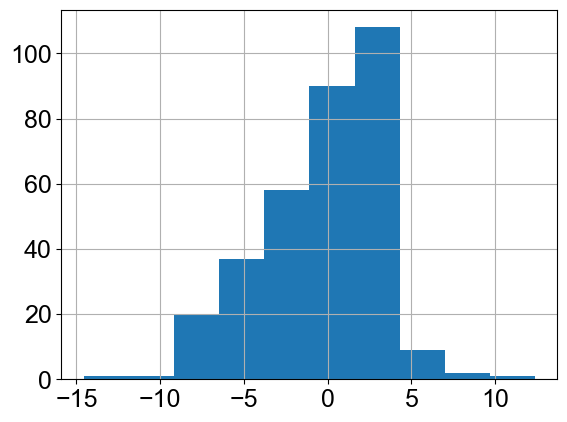

In [463]:
long.avg_lateral_error.hist()

In [465]:
long.lateral_error

3      [0.7024553840237395, 0.7188568915974791, 0.747...
5      [2.2301078349304326, 2.2607067022205563, 2.317...
7      [2.6921545159109286, 2.6843484121234873, 2.673...
15     [3.1218889376039307, 3.1030073526188247, 3.064...
23     [2.044850948488161, 2.033026413605775, 2.01166...
                             ...                        
863    [-2.2155438365408173, -2.24389015781955, -2.29...
871    [-3.3237261248795917, -3.3358168115654507, -3....
873    [-4.367018664406565, -4.369745333294549, -4.37...
875    [-4.452796905091791, -4.442610880639055, -4.42...
877    [-2.9320350692254102, -2.919802856968346, -2.8...
Name: lateral_error, Length: 327, dtype: object

In [466]:
F3LILT_TT_gaze_df

,animal,date,gaze_onset_index,gaze_timestamp,window_left,window_right,window_size,has_nan,is_zero,gaze_direction,dGaze_value,cluster
0,F3LILT,051325,78,0.629773,6,15,22,False,False,left,251.500473,0
1,F3LILT,051325,81,0.679610,6,15,22,False,False,left,354.582225,0
2,F3LILT,051325,84,0.729920,6,15,22,False,False,left,390.833279,1
3,F3LILT,051325,95,0.914112,6,15,22,False,False,left,1020.701578,0
4,F3LILT,051325,109,1.148077,6,15,22,False,False,left,625.149695,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1352,F3LITT,050725,76267,1271.888230,6,15,22,False,False,right,-323.817400,0
1353,F3LITT,050725,76321,1272.788281,6,15,22,False,False,right,-292.850515,3
1354,F3LITT,050725,76324,1272.836736,6,15,22,False,False,right,-254.157783,3
1355,F3LITT,050725,76349,1273.256518,6,15,22,False,False,right,-256.430384,3


In [468]:
F3LILT_TT_imu_df

,animal,date,Usegood_reflec,spot_count,ellipticity,usegood_ellipcalb,ellipse,scale,cam_cent,pupil_count,...,eyeT,gazeL_event,gazeL_idx,gazeR_event,gazeR_idx,compL_event,compL_idx,compR_event,compR_idx,usegood_eyecalib
0,F3LILT,050925,"[True, True, True, True, True, True, True, Tru...","[5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, ...","[0.4273056253988108, 0.8387024833010754, 0.834...","[[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13...","[[3.682610401976506, 0.8658490039526463, 1.015...",34.368146,"[[12.60676530840216], [17.758242531405756]]","[8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, ...",...,"[-0.6529539999974077, -0.6388165000025765, -0....","[0.02735949999623699, 0.22762900000088848, 0.5...","[41, 53, 75, 90, 104, 109, 130, 146, 170, 189,...","[-0.07252499999594875, 0.2752000000036787, 0.3...","[35, 56, 60, 77, 79, 84, 99, 103, 111, 118, 13...","[-0.08851199999480741, -0.04061449999426259, 0...","[34, 37, 46, 50, 64, 81, 86, 110, 122, 126, 12...","[-0.15685099999973318, -0.02469099999871105, 0...","[30, 38, 40, 42, 45, 57, 59, 62, 72, 76, 78, 8...","[True, True, True, True, True, True, True, Tru..."
1,F3LILT,050725,"[False, False, True, True, True, True, True, T...","[0, 0, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, ...","[0.7606406438901715, 0.723676532184688, 0.7891...","[[3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15,...","[[nan, nan, nan, nan, nan, nan, nan, nan, nan,...",50.319602,"[[10.61569243188819], [30.772549956537468]]","[0, 0, 6, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, ...",...,"[-0.6478980000028969, -0.6379395000039949, -0....","[0.12053149999701418, 0.4407680000003893, 1.02...","[47, 66, 101, 136, 157, 162, 171, 179, 190, 19...","[0.6041980000009062, 0.7042299999957322, 1.056...","[76, 82, 103, 166, 200, 229, 237, 272, 309, 32...","[-0.1457665000052657, 0.07235799999762094, 0.1...","[31, 44, 50, 54, 58, 68, 86, 88, 105, 108, 111...","[-0.06367999999929452, 0.10428200000023935, 0....","[36, 46, 48, 55, 64, 72, 74, 78, 84, 96, 102, ...","[False, False, False, True, True, True, True, ..."
2,F3LILT,050825,"[False, False, True, True, True, True, True, T...","[0, 0, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, ...","[0.5662960757750525, 0.7646919405145582, 0.795...","[[2, 3, 4, 8, 9, 15, 16, 17, 18, 19, 20, 21, 2...","[[nan, nan, nan, nan, nan, nan, nan, nan, nan,...",39.284740,"[[9.871423020569777], [20.53456711306859]]","[0, 0, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, ...",...,"[-0.6464899999991758, -0.6435589999964577, -0....","[-0.14068499999848427, 1.1455040000000736, 1.2...","[32, 109, 116, 123, 130, 231, 254, 324, 336, 3...","[-0.15647399999579648, -0.10423099999752594, 0...","[31, 34, 86, 113, 120, 133, 178, 189, 204, 225...","[-0.07243600000219885, 0.027712000002793502, 0...","[36, 42, 46, 58, 61, 67, 70, 72, 76, 80, 94, 1...","[-0.05623750000086147, 0.0599549999969895, 0.1...","[37, 44, 49, 59, 65, 68, 77, 84, 88, 103, 145,...","[False, False, True, True, True, True, True, T..."
3,F3LILT,051225,"[True, True, True, True, True, True, True, Tru...","[5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, ...","[[0.45233519456633525], [0.8403882997020614], ...","[[0, 18, 19, 20, 32, 33, 34, 35, 36, 37, 38, 4...","[[5.41835388411787, 0.8397149738151738, 1.0050...",42.886137,"[[12.82194860346359], [17.694172412204665]]","[8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, ...",...,"[-0.6260099999999511, -0.611308999999892, -0.5...","[0.5877055000019027, 2.0718720000004396, 3.791...","[73, 162, 265, 271, 312, 368, 376, 383, 391, 4...","[0.2715140000000247, 1.4036859999978333, 2.055...","[54, 122, 161, 168, 175, 177, 289, 301, 305, 3...","[-0.11247350000485312, -0.04645149999851128, 0...","[31, 35, 40, 45, 61, 64, 70, 76, 80, 83, 85, 8...","[-0.14628499999525957, -0.08044800000061514, -...","[29, 33, 36, 39, 42, 52, 58, 63, 66, 75, 87, 9...","[True, True, True, True, True, True, True, Tru..."
4,F3LILT,051325,"[False, False, True, True, True, True, True, T...","[0, 0, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, ...","[0.5481884232673886, 0.5528403

In [ ]:
F3LILT_TT_df = pd.read_hdf(r"\\goeppert\Vol2\mike\metadata\gaze_shift\data\F3LILT_F3LITT_all_data_df.h5")

F3LILT_TT_imu_df =pd.read_hdf(r"\\goeppert\Vol2\mike\metadata\gaze_shift\data\F3LILT_F3LITT_all_imu_data_df.h5")

F3LILT_TT_gaze_df =pd.read_hdf(r"\\goeppert\Vol2\mike\metadata\gaze_shift\data\F3LILT_F3LITT_all_gaze.h5")

In [467]:
long

,first_poke,second_poke,trial_timestamps,trial_vidframes,arenaTL_T_x,arenaTL_T_y,arenaTL_T_likelihood,arenaTR_T_x,arenaTR_T_y,arenaTR_T_likelihood,...,goal_head_cen_y,goal_basis_start_x,goal_basis_start_y,goal_basis_end_x,goal_basis_end_y,obstacle_devations,goal_devations,start,lateral_error,avg_lateral_error
3,46627.276403,46645.984563,"[46627.289958, 46627.306585, 46627.323238, 466...","[[3288, 3289, 3290, 3291, 3292, 3293, 3294, 32...",30.555741,39.853508,"[0.9582122564315796, 0.9644008278846741, 0.965...",847.509583,41.619534,"[0.9905883073806763, 0.9928293824195862, 0.992...",...,"[21.750450481533843, 21.7885562370761, 21.8208...",27.466223,21.750450,58.121618,22.242900,"[nan, 29.236293476253568, 28.649602823466143, ...","[nan, 4.611780167134981, 4.154541728959622, 3....",top,"[0.7024553840237395, 0.7188568915974791, 0.747...",0.657804
5,46655.045644,46668.596608,"[46655.054553, 46655.07127, 46655.087948, 4665...","[[4953, 4954, 4955, 4956, 4957, 4958, 4959, 49...",30.555741,39.853508,"[0.9712257385253906, 0.9792014360427856, 0.973...",847.509583,41.619534,"[0.989385187625885, 0.991332471370697, 0.99085...",...,"[23.487535938436164, 23.50490737829043, 23.503...",27.490897,23.487536,58.186864,22.684526,"[nan, 33.42447705605846, 33.492877014212546, 3...","[nan, 4.989696767174578, 3.047711172870898, 0....",top,"[2.2301078349304326, 2.2607067022205563, 2.317...",3.851213
7,46676.076505,46687.353792,"[46676.082393, 46676.098995, 46676.116032, 466...","[[6214, 6215, 6216, 6217, 6218, 6219, 6220, 62...",30.555741,39.853508,"[0.9867097735404968, 0.9854205250740051, 0.984...",847.509583,41.619534,"[0.9895985126495361, 0.9934015870094299, 0.993...",...,"[22.81068402475916, 22.69114377927036, 22.5410...",27.726119,22.810684,57.105029,21.903440,"[nan, 7.09250741223221, 6.363922890668041, 5.4...","[nan, 9.231920067738834, 10.55877472990407, 11...",top,"[2.6921545159109286, 2.6843484121234873, 2.673...",3.074957
15,46779.391155,46790.247014,"[46779.403532, 46779.420224, 46779.436864, 467...","[[12410, 12411, 12412, 12413, 12414, 12415, 12...",30.555741,39.853508,"[0.9810381531715393, 0.9854135513305664, 0.968...",847.509583,41.619534,"[0.9953794479370117, 0.9969102740287781, 0.996...",...,"[23.696335772782508, 23.685316312814976, 23.65...",27.709031,23.696336,58.112843,22.920202,"[nan, 41.31229695104417, 43.30646933884542, 45...","[nan, 0.13823060773908338, 1.6126717052988004,...",top,"[3.1218889376039307, 3.1030073526188247, 3.064...",3.410291
23,46862.289433,46879.113395,"[46862.297523, 46862.31424, 46862.331059, 4686...","[[17381, 17382, 17383, 17384, 17385, 17386, 17...",30.555741,39.853508,"[0.9832825064659119, 0.9777345061302185, 0.984...",847.509583,41.619534,"[0.9952711462974548, 0.9954094290733337, 0.995...",...,"[22.894398759613647, 22.877228298029113, 22.88...",27.837420,22.894399,58.274998,22.896885,"[nan, 32.57754773228459, 31.8903581387838, 30....","[nan, 2.4190241829563477, 0.95060054704734, 0....",top,"[2.044850948488161, 2.033026413605775, 2.01166...",3.061476
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
863,57946.733478,57955.552998,"[57946.742835, 57946.759795, 57946.776204, 579...","[47506, 47507, 47508, 47509, 47510, 47511, 475...",30.500332,39.820435,"[0.9832699298858643, 0.9731746912002563, 0.976...",847.892883,41.564779,"[0.9942779541015625, 0.9933854937553406, 0.993...",...,"[21.86131063407943, 21.81924620073305, 21.7999...",32.443147,21.861311,8.149634,22.098239,"[nan, 89.59218476408765, 88.18407267176408, 86...","[nan, 12.249394358492154, 9.572412648361876, 7...",bottom,"[-2.2155438365408173, -2.24389015781955, -2.29...",-1.588452
871,58079.726310,58102.330124,"[58079.729664, 58079.746611, 58079.763072, 580...","[55481, 55482, 55483, 55484, 55485, 55486, 554...",30.500332,39.820435,"[0.9740180969238281, 0.9811832904815674, 0.979...",847.892883,41.564779,"[0.9885184168815613, 0.9901294112205505, 0.991...",...,"[21.250650404098458, 21.258106638996, 21.25884...",33.7646